# 1.	Data Pre-processing and exploration

## a.	Report the class balance of the whole dataset

Through the initial data exploration, I observed a significant class imbalance within the dataset. Specifically, Class 7 accounts for a substantially larger proportion of samples, while many other classes are minimally represented. This imbalance is critical as it introduces prediction bias, where the model will inherently tend to favor and predict the majority class. 

Consequently, this necessitates careful consideration in our subsequent data pre-processing, model selection, and evaluation strategies.

**Firstly**, before we start, we need to load the dataset. I've written this process **into a function**, so in the future, we can simply call the function to import the data (no matter train data or test data).

In [1]:
import zipfile
import pandas as pd
import io 
import os

# --- File Paths and Parameters ---

ZIP_FILE = 'MLT-CW-Dataset.zip' # ZIP file containing the dataset

# Mapping of integer labels to activity names
LABEL_MAPPING = {
    1: 'Walking', 2: 'Running', 3: 'Shuffling', 
    6: 'Standing', 7: 'Sitting', 8: 'Lying',
    9: 'Stairs', # Consolidated label with 4(stairs (ascending)) and 5(stairs (descending))
}

def load_data_from_zip_by_type(zip_path, data_type='train', include_S007=True, need_to_print=True):
    """
    Loads raw time-series data from CSV files within a ZIP archive.
    """

    all_dfs = []
    
    with zipfile.ZipFile(zip_path, 'r') as z:
        file_list = z.namelist()
        
        for file_name in file_list:
            # Check if the file is a CSV file
            if file_name.endswith('.csv'):
                
                # --- 1. Filter by data_type (train/test) ---
                is_test_file = file_name.startswith('test-set/')
                if data_type == 'train' and is_test_file:
                    continue 
                if data_type == 'test' and not is_test_file:
                    continue

                # Extract subject ID from the filename
                subject_id = os.path.basename(file_name).replace('.csv', '')
                
                # --- 2. Filter by subject ID (S007 exclusion logic) ---
                if not include_S007 and subject_id == 'S007':
                    print(f"Skipping S007 data as requested: {file_name}")
                    continue
                # ----------------------------------------------------
                if(need_to_print == True):
                    print(f"Load data: {file_name}")
                with z.open(file_name) as file:
                    df = pd.read_csv(io.BytesIO(file.read()))
                    df['subject'] = subject_id  # Add subject ID column
                    df['file_source'] = file_name # Optional: Keep full file path
                    all_dfs.append(df)

    if not all_dfs:
        return pd.DataFrame()

    # Concatenate all loaded DataFrames into a single one
    return pd.concat(all_dfs, ignore_index=True)

In [2]:
print("--- 0. Data Loading: Load the training set (excluding the test set).")
df_raw = load_data_from_zip_by_type(ZIP_FILE, data_type='train')


--- 0. Data Loading: Load the training set (excluding the test set).
Load data: S007.csv
Load data: S008.csv
Load data: S009.csv
Load data: S012.csv
Load data: S013.csv
Load data: S014.csv
Load data: S015.csv
Load data: S016.csv
Load data: S017.csv
Load data: S018.csv
Load data: S020.csv
Load data: S022.csv
Load data: S023.csv
Load data: S025.csv
Load data: S026.csv
Load data: S027.csv
Load data: S028.csv
Load data: S006.csv


Now that the dataset is loaded, we can proceed with generating our visualizations. We'll start by importing the necessary libraries.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from typing import Optional

Then, calculate the percentage of each class for the preparation of the figures.

In [4]:
category_counts = df_raw['label'].value_counts()

# Calculate the percentage of each class for the preparation of the figures
category_percentage = df_raw['label'].value_counts(normalize=True) * 100

In [5]:
def plot_class_distribution(df: pd.DataFrame, filename: Optional[str] = None):
    """
    Generates a sorted bar chart (Count Plot) for the 'label' column, including 
    exact count annotation`s and custom formatting for large numbers.
    """
    
    # Configuration for Matplotlib display
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans'] 
    plt.rcParams['axes.unicode_minus'] = False 

    plt.figure(figsize=(10, 6))

    # Calculate and sort the counts for plotting order (按标签值排序)
    category_counts = df['label'].value_counts().sort_index()

    # Define a formatter function to add comma separators to large numbers
    def thousands_formatter(x, pos):
        return f'{int(x):,}' 

    # Generate the Count Plot using Seaborn
    ax = sns.countplot(
        data=df, 
        x='label', 
        order=category_counts.index, 
        palette='Spectral', 
        hue='label',
        legend=False 
    )

    # Apply formatting to Y-axis
    plt.ticklabel_format(style='plain', axis='y')
    ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
    
    # Add data labels (exact counts) on top of each bar
    for p in ax.patches:
        ax.annotate(
            f'{p.get_height():,}', 
            (p.get_x() + p.get_width() / 2., p.get_height()), 
            ha='center', 
            va='baseline', 
            fontsize=9, 
            color='black', 
            xytext=(0, 5), 
            textcoords='offset points',
            weight='bold'
        )

    # Set titles and labels for the report
    plt.title('Activity Class Distribution Report', fontsize=18, weight='bold', pad=20)
    plt.xlabel('Activity Label', fontsize=14)
    plt.ylabel('Number of Samples', fontsize=14)

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout() 

    # Save the plot if a filename is provided
    if filename:
        plt.savefig(filename)
    else:
        plt.show()

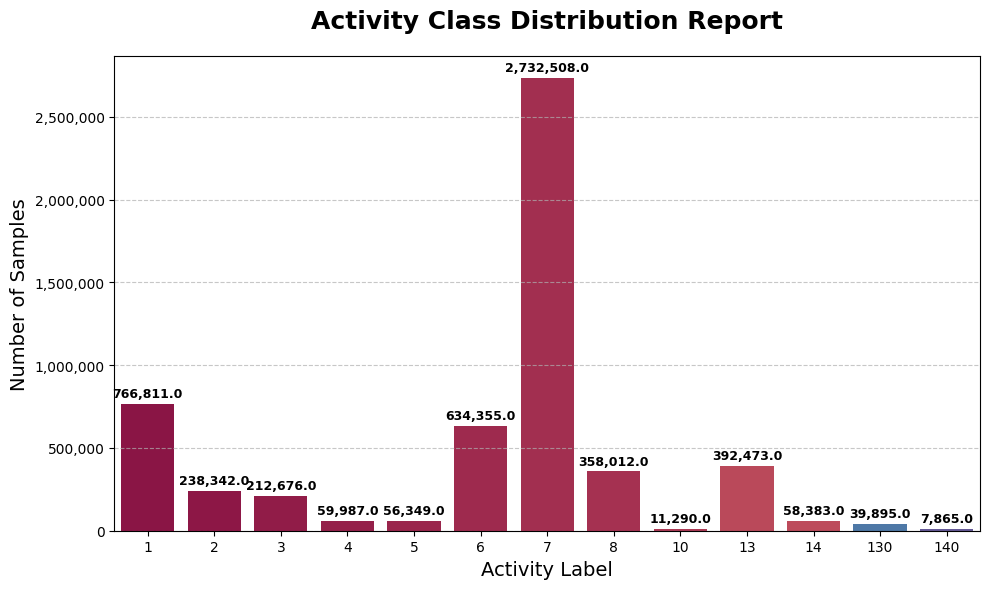

In [6]:
plot_class_distribution(df_raw)

From this chart, we can draw the following conclusions:
* **Class Imbalance Diagnosis**: The chart reveals **severe class imbalance**. Label 7 (2.7M+) is the dominant majority class, while classes like Label 140 (7,865) are minimally represented.

* **Model Impact**: This imbalance will cause **prediction bias**, favoring the high-frequency Label 7. Consequently, the model will struggle to achieve the minimum **Recall** and **Precision** requirements for the minority classes specified. 

We can more intuitively visualize this data imbalance by plotting a pie chart, as Class 7 alone accounts for nearly half of the total proportion.

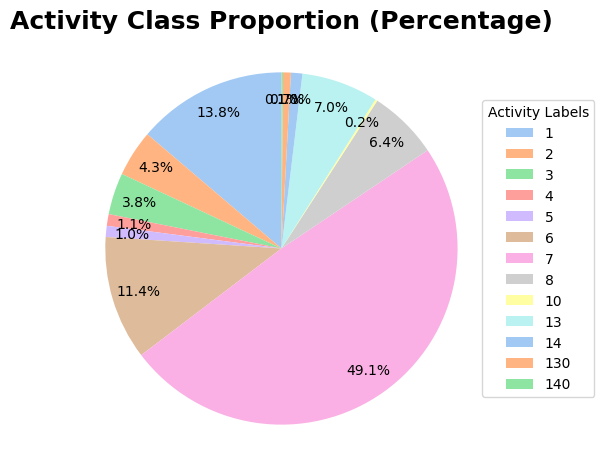

In [7]:
# Calculate and sort the counts for plotting order
category_counts = df_raw['label'].value_counts().sort_index()
# Prepare labels and sizes for the pie chart
labels = category_counts.index 
sizes = category_counts.values

# 2. Create the chart figure
plt.figure(figsize=(5, 5))

# 3. Plot the pie chart
plt.pie(
    sizes,
    # autopct: format the percentage (e.g., '1.1%')
    autopct='%1.1f%%', 
    startangle=90,      
    colors=sns.color_palette('pastel'), 
    pctdistance=0.85    
)

# 4. Display labels in an external legend
plt.legend(
    labels, 
    title="Activity Labels",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1) # Place legend to the right of the plot
)

# 5. Set the title and ensure the chart is circular
plt.title('Activity Class Proportion (Percentage)', fontsize=18, weight='bold', pad=20)
plt.axis('equal') 

plt.show()

## b.	Function Writing and Application: Drop Cycling Data

In this module, we will write a function to drop data labelled with any type of cycling because the company is not currently interested in them. 


In [8]:
def drop_cycling_data(df: pd.DataFrame, need_to_print=True) -> pd.DataFrame:
    """
    Drops all rows from the DataFrame where the 'label' column matches any cycling label.
    """
    cycling_labels = [13, 14, 130, 140] 
    # 1. Get initial dataset size
    initial_size = df.shape[0]

    # 2. Filter out rows where 'label' is in the cycling_labels list
    # The '~' inverts the condition (keeps rows NOT in the list)
    df_filtered = df[~df['label'].isin(cycling_labels)].copy()
    
    # 3. Get new dataset size and calculate removed rows
    new_size = df_filtered.shape[0]
    removed_rows = initial_size - new_size

    # 4. Report the results
    if(need_to_print== True):
        print("--- Data Dropping Report (Cycling Data) ---")
        print(f"Initial Dataset Size (Rows): {initial_size:,}")
        print(f"Cycling Labels to be Removed: {cycling_labels}")
        print(f"Removed Rows: {removed_rows:,}")
        print(f"New Dataset Size (Rows) to Report: {new_size:,}")
        print("------------------------------------------")
    
    # 5. Return the cleaned DataFrame
    return df_filtered

As demonstrated in the data balance investigation in Part a, the data pertaining to cycling activities comprises the sum of classes 13, 14, 130, and 140. We could calculate the sum of these data volumes: $392,473 + 58,383 + 39,895 + 7,865 = 498,616$.

In [9]:
CYCLING_LABELS_TO_SUM = [13, 14, 130, 140]
cycling_sum = category_counts.loc[CYCLING_LABELS_TO_SUM].sum()
print(f"Total number of samples for cycling data is {cycling_sum}")

Total number of samples for cycling data is 498616


Then we could apply it to the dataset and report the new dataset size.

In [10]:
df_cleaned = drop_cycling_data(df_raw)

--- Data Dropping Report (Cycling Data) ---
Initial Dataset Size (Rows): 5,568,946
Cycling Labels to be Removed: [13, 14, 130, 140]
Removed Rows: 498,616
New Dataset Size (Rows) to Report: 5,070,330
------------------------------------------


The number of **Removed Rows** confirms we have correctly purged all cycling-related data.

## c.	Function Writing and Application: Merge stairs-related data

In this module, we will Write a function to merge the stairs (ascending) and stairs (descending) labels in a single class “stairs” with code 9, as the company wants to consider them as a single action.

In [11]:
def merge_stairs_labels(df: pd.DataFrame, need_to_print=True) -> pd.DataFrame:
    """
    Merges 'Stairs (ascending)' (Label 4) and 'Stairs (descending)' (Label 5) 
    into a single consolidated class 'Stairs' with the new Label 9.
    """

    ORIGINAL_STAIRS_LABELS = [4, 5]
    NEW_STAIRS_LABEL = 9

    df_merged = df.copy() # Work on a copy for safety
    
    # 1. Get and print original counts for Labels 4 and 5
    count_4_orig = df_merged['label'].value_counts().get(4, 0)
    count_5_orig = df_merged['label'].value_counts().get(5, 0)
    
    if(need_to_print== True):
        print("--- Label Merging Pre-Check ---")
        print(f"Original Count (Label 4): {count_4_orig:,}")
        print(f"Original Count (Label 5): {count_5_orig:,}")
        print(f"Expected New Label 9 Total: {(count_4_orig + count_5_orig):,}")
        print("-------------------------------")
    
    # 2. Execute the merge operation
    df_merged.loc[df_merged['label'].isin(ORIGINAL_STAIRS_LABELS), 'label'] = NEW_STAIRS_LABEL
    
    # 3. Final Report (Post-Check & Verification)
    
    # Get the counts AFTER merging for verification
    final_count_9 = df_merged['label'].value_counts().get(NEW_STAIRS_LABEL, 0)
    final_count_4 = df_merged['label'].value_counts().get(4, 0)
    final_count_5 = df_merged['label'].value_counts().get(5, 0)
    
    if(need_to_print== True):
        print("--- Label Merging Final Report ---")
        print(f"Labels {ORIGINAL_STAIRS_LABELS} successfully merged into Label {NEW_STAIRS_LABEL}.")
        print(f"Total instances of Label {NEW_STAIRS_LABEL} are now: {final_count_9:,}")
    
    # Print the verification results (should be 0)
    if(need_to_print== True):
        print("--- Verification of Removal ---")
        print(f"Final Count of Old Label 4: {final_count_4:,}")
        print(f"Final Count of Old Label 5: {final_count_5:,}")
        print("----------------------------------")
    
    return df_merged

As demonstrated in the data balance investigation in Part a, the data pertaining to stairs-related comprises the sum of classes 4 and 5. We could calculate the sum of these data volumes: $59,987 + 56,349 = 116,336$.

In [12]:
STAIRS_LABELS_TO_SUM = [4, 5]
stairs_sum = category_counts.loc[STAIRS_LABELS_TO_SUM].sum()
print(f"Total number of samples for stairs-related data is {stairs_sum}")

Total number of samples for stairs-related data is 116336


Then we could apply it to the dataset and report the new dataset size.

In [13]:
df_merged = merge_stairs_labels(df_cleaned)

--- Label Merging Pre-Check ---
Original Count (Label 4): 59,987
Original Count (Label 5): 56,349
Expected New Label 9 Total: 116,336
-------------------------------
--- Label Merging Final Report ---
Labels [4, 5] successfully merged into Label 9.
Total instances of Label 9 are now: 116,336
--- Verification of Removal ---
Final Count of Old Label 4: 0
Final Count of Old Label 5: 0
----------------------------------


The total count of **Label 9** confirms we have correctly merged all stairs-related data. Furthermore, the absence of **Label 4** and **Label 5** verifies this operation

## d.	Function Writing and Application: report and interpret data patterns of the “Walking”

In this module, we will use appropriate sampling and visualisations to report and interpret data patterns of the “Walking” class in the dataset.

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from typing import List

For this function, there are three main part:
* **Sampling:** It extracts a **random, continuous time segment** (e.g., 10 seconds) to ensure the visualization captures clear, repetitive patterns (like a full gait cycle) without overwhelming the plot.
*  **Layout Setup:** It creates a **$3 \times 2$ subplot grid** using Matplotlib, dedicated to displaying the six sensor axes.
*  **Visualization:** It plots the acceleration values over time for all six axes, allowing analysts to visually **interpret the unique physical signatures** of each activity.

In [15]:
def visualize_patterns_by_label(df_input: pd.DataFrame, all_labels: List[int], duration_s: int, rate_hz: int, size_a:int ,size_b:int):
    """
    Samples a 10-second segment for each specified activity label and visualizes 
    its time-series pattern across all 6 sensor axes.
    """
    
    # Sensor columns (6 axes) and their corresponding titles
    sensor_cols = ['back_x', 'back_y', 'back_z', 'thigh_x', 'thigh_y', 'thigh_z']
    sensor_titles = [
        'Back X-Axis (g)', 'Back Y-Axis (g)', 'Back Z-Axis (g)',
        'Thigh X-Axis (g)', 'Thigh Y-Axis (g)', 'Thigh Z-Axis (g)'
    ]
    
    # Map label codes to activity names (Needs full mapping based on dataset context)
    label_map = {
        1: 'Walking', 
        2: 'Running',
        3: 'Shuffling',
        6: 'Standing',
        7: 'Sitting',
        8: 'Lying',
        9: 'Stairs',
    }
    
    # Calculate total number of samples required
    sample_size = duration_s * rate_hz
    
    # Iterate through all specified labels
    for label in all_labels:
        # 1. Filter data for the target activity
        df = df_input[df_input['label'] == label].reset_index(drop=True)
        activity_name = label_map.get(label, f'Label {label}')

        # 2. Randomly sample a continuous segment
        start_index = np.random.randint(0, len(df) - sample_size)
        df_sample = df.loc[start_index : start_index + sample_size - 1].copy()

        # 3. Create relative time axis (in seconds)
        df_sample['Time (s)'] = np.arange(len(df_sample)) / rate_hz
        
        # 4. Create Figure and Axes object (3 rows, 2 columns)
        fig, axes = plt.subplots(
            nrows=3, 
            ncols=2, 
            figsize=(size_a, size_b), 
            sharex=True # Share X-axis across all subplots
        )
        axes = axes.flatten() 
        
        # 5. Plot the time series for all sensor axes
        for i, col in enumerate(sensor_cols):
            df_sample.set_index('Time (s)')[col].plot(
                ax=axes[i], 
                title=sensor_titles[i], 
                legend=False,
                color=sns.color_palette('Spectral', 6)[i] 
            )
            axes[i].set_ylabel("Accel. (g)") # Set Y-axis label

        # 6. Set overall titles and labels
        plt.suptitle(f'Time-Series Pattern of "{activity_name}" (Label {label}) - {duration_s}s Segment', 
                     fontsize=18, y=1.02)
        
        # Add X-axis label only to the bottom subplots
        for ax in axes[4:]:
            ax.set_xlabel("Time (s)")

        plt.tight_layout(rect=[0, 0.03, 1, 0.98]) 
        
        plt.show()

def plot_timeseries(dataFrame: pd.DataFrame, 
                   sampling_frequency: float, 
                   time_s: float, 
                   start_time_s: float = 0.0,
                   columns_to_plot: list = None):
    """
    Function designed for plotting time series data across six separate axes (subplots).
    It plots a section of data defined by a start time and a duration.
    """

    # Validate columns_to_plot if provided
    if columns_to_plot is not None:
        # Check if all specified columns exist in DataFrame
        missing_cols = [col for col in columns_to_plot if col not in dataFrame.columns]
        
        # Limit to maximum 6 columns
        if len(columns_to_plot) > 6:
            columns_to_plot = columns_to_plot[:6]
        elif len(columns_to_plot) == 0:
            return
    
    # 1. Calculate the starting and ending indices for slicing
    start_index = int(start_time_s * sampling_frequency)
    end_index = int((start_time_s + time_s) * sampling_frequency)
    
    # Check end boundary
    if end_index > len(dataFrame):
        # If requested end time exceeds data length
        data_to_plot = dataFrame.iloc[start_index:]
        actual_time_s = len(data_to_plot) / sampling_frequency
    else:
        # Slice the required range of data
        data_to_plot = dataFrame.iloc[start_index:end_index]
        actual_time_s = time_s

    # 2. Generate the Time Axis (X-axis)
    time_step = 1.0 / sampling_frequency
    time_axis = np.array([start_time_s + i * time_step for i in range(len(data_to_plot))])
    
    # 3. Identify signal columns to plot
    if columns_to_plot is None:
        # Auto-select columns if not specified
        columns_to_exclude = ['timestamp', 'label', 'Time (s)', 'Time(s)', 'index', 'id'] 
        signal_columns = [col for col in data_to_plot.columns 
                         if col.lower() not in [c.lower() for c in columns_to_exclude]]
            
        columns_to_plot = signal_columns[:6]
        
    num_axes = len(columns_to_plot)
    
    # Plotting: Create subplot layout based on number of columns
    fig, axes = plt.subplots(nrows=num_axes, ncols=1, figsize=(12, 2*num_axes), sharex=True)
    
    # Handle single subplot case
    if num_axes == 1:
        axes = [axes]
    
    # Set the overall title for the figure
    title_suffix = f" (User-selected)" if columns_to_plot is not None else f" (Auto-selected)"
    fig.suptitle(f"{num_axes}-Axis Time Series Plot{title_suffix}\n"
                f"Fs: {sampling_frequency} Hz, Start Time: {start_time_s:.2f} s, "
                f"Plotted Duration: {actual_time_s:.2f} s", 
                fontsize=14)

    # Iterate and plot each signal on its dedicated axis
    for i, column in enumerate(columns_to_plot):
        ax = axes[i]
        
        # Plot the signal
        ax.plot(time_axis, data_to_plot[column], label=column, color=f'C{i}', linewidth=1.5)
        
        # Set Y-axis label and title
        ax.set_ylabel(f"{column}", fontsize=10)
        ax.set_title(f"Signal: {column}", fontsize=11, loc='left', pad=5)
        ax.grid(True, linestyle='--', alpha=0.6)
        
        # Add legend
        ax.legend(loc='upper right', fontsize=9)
        
        # Adjust Y-axis limits based on data
        y_data = data_to_plot[column]
        y_range = y_data.max() - y_data.min()
        if y_range > 0:
            margin = y_range * 0.1
            ax.set_ylim(y_data.min() - margin, y_data.max() + margin)
        
        ax.tick_params(axis='y', labelsize=8)
    axes[-1].set_xlabel("Time (seconds)", fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    plt.show()

From the paper of HARTH-Dataset, we can draw the rate of the sensor is 100Hz. So we could also define the rate as 100Hz.


Most crucially, We could compare Walking against three other activity types to highlight its **key features** for classification.

1. Running (Periodic & High-Intensity)
* **Purpose:** To define the **upper bounds of energy** and **cadence**.
* **Key Distinction:** Running has **higher frequency** and **larger amplitude** in the acceleration signals than walking, clearly distinguishing the two energy levels despite their shared **periodicity**.

2. Climbing Stairs (Periodic & Vertical Change)

* **Purpose:** To distinguish **horizontal** movement (Walking) from movement with significant **vertical displacement**.
* **Key Distinction:** Stair climbing signals show **mean drift or asymmetry** on the vertical axes (Back X/Thigh X), reflecting a continuous vertical climb. Walking signals remain **stable** along the vertical axis, confirming its core characteristic is **horizontal translation**.

3. Standing/Rest (Non-Periodic Baseline)

* **Purpose:** To **prove the dynamic, periodic nature** of walking.
* **Key Distinction:** Standing signals **lack periodicity** and have **minimal amplitude**, essentially serving as a static baseline. This comparison confirms that the primary feature of "Walking" is the presence of **regular, quantifiable periodic signal energy**. 

In [16]:
ALL_LABELS = {1, 2, 6, 9} # The label code to 'Walking' 'Standing' ‘Running’ and 'Stairs'
SAMPLING_RATE_HZ = 100 # The sensor data acquisition rate in Hertz (Hz), meaning 100 samples per second
VISUAL_DURATION_SECONDS = 10 # 10-second window 

Now, we could draw a 10s segment of the Walking' 'Standing' ‘Running’ and 'Stairs' activities and visualizes its time-series pattern with 6 correctly titled subplots.

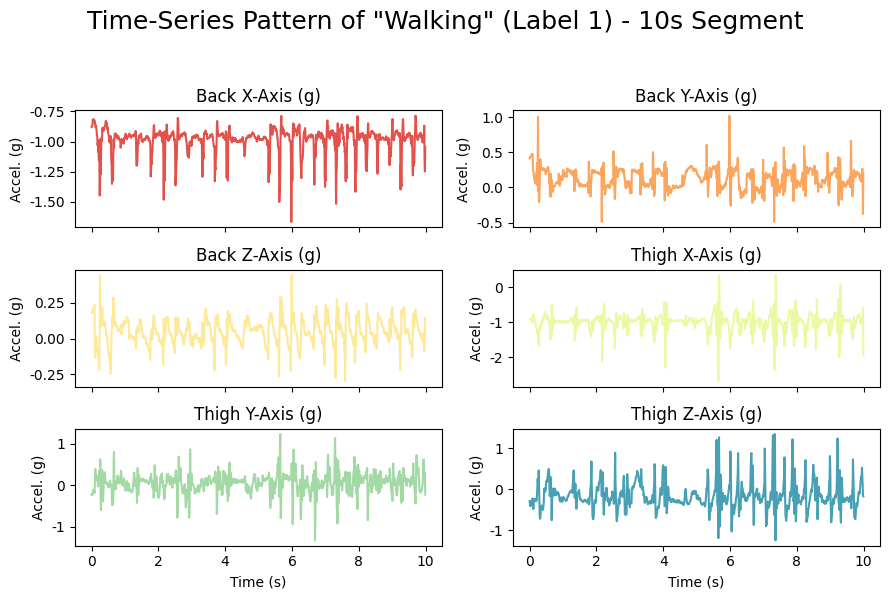

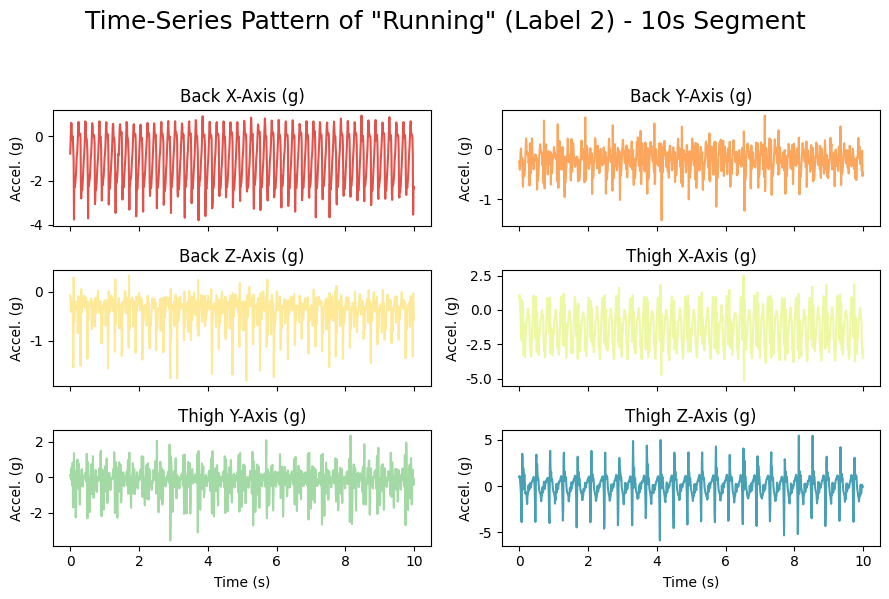

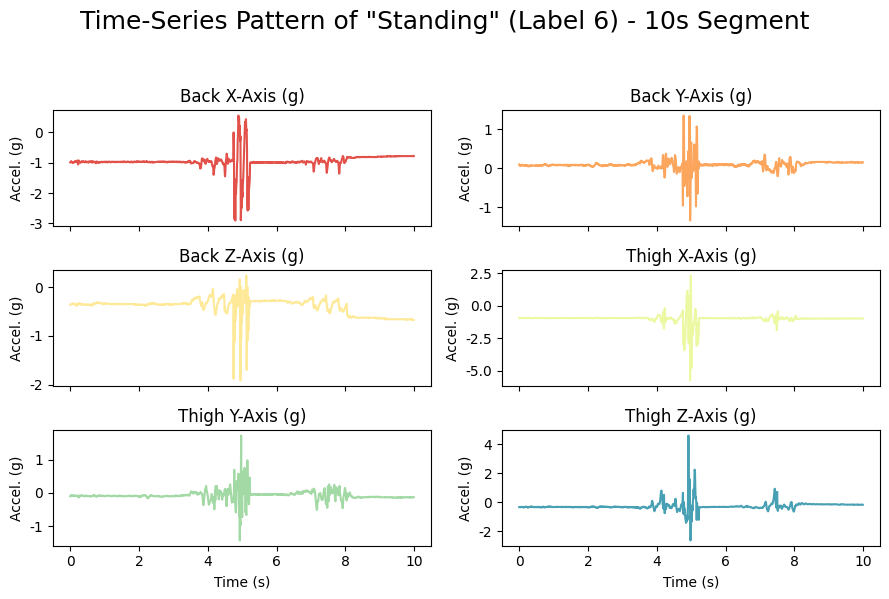

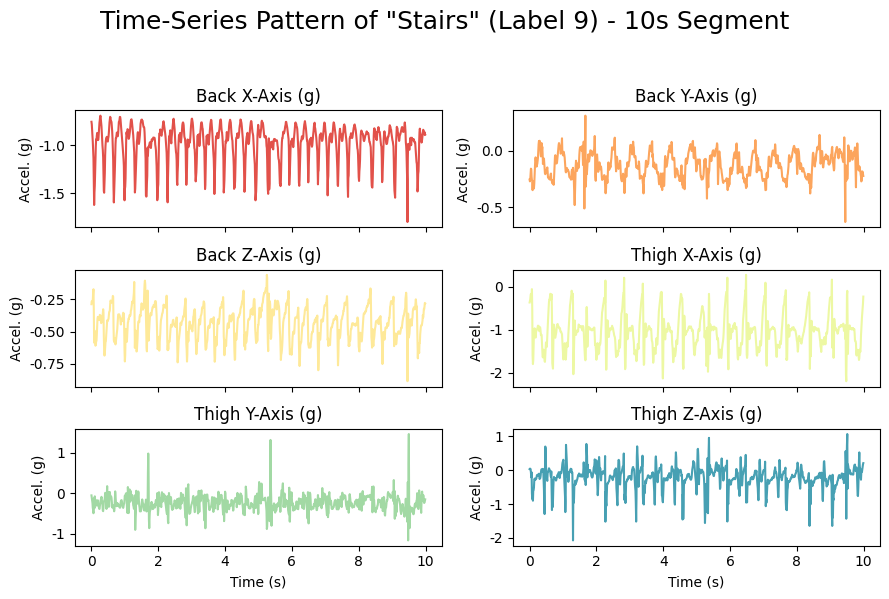

In [17]:
visualize_patterns_by_label(
    df_input=df_merged, 
    all_labels=ALL_LABELS, 
    duration_s=VISUAL_DURATION_SECONDS, 
    rate_hz=SAMPLING_RATE_HZ,
    size_a=9,  
    size_b=6
)

Based on this comparison, we can now clearly **draw the conclusions** regarding the data patterns of the “Walking” class.


---

###  Conclusions on the "Walking" Data Pattern

The analysis confirms that "Walking" is a **periodic, mid-energy activity** defined by stable, rhythmic oscillations. Its distinct pattern is characterized by the following features:

#### 1. **Core Feature: Stable Periodicity**

* "Walking" exhibits **clear, sustained, and regular sinusoidal-like oscillations** across all four primary axes: **Back X, Back Z, Thigh X, and Thigh Z**.
* This stable rhythmicity is the fundamental feature that separates it from non-periodic activities like "Standing".

#### 2. **Energy and Amplitude Range (vs. Running)**

* "Walking" is a **mid-energy activity**. Its signals show a **significantly lower dynamic range and amplitude** compared to the high-intensity **"Running"** pattern.
    * *Example:* The peak-to-peak amplitude on the **Thigh Z-Axis** for Walking is approximately $\pm 2.0\ g$ to $2.5\ g$, which is much smaller than the $\pm 5.0\ g$ range observed in Running.
* The signal **frequency (cadence)** for Walking is also visibly **lower** (waves are less dense) than that of Running.

#### 3. **Postural Stability (vs. Stairs)**

* The **Vertical Trunk Movement (Back X-Axis)** for Walking is **stable**, oscillating around a consistent gravitational mean (approximately $-1.5\ g$).
* This pattern **lacks the mean drift or visible baseline shift** observed in **"Stairs"**, confirming that "Walking" is primarily characterized by **horizontal translation** rather than continuous vertical ascent/descent.

#### 4. **Key Axis Activity**

* The **Thigh Z-Axis (Longitudinal)** provides the most dynamic signal, directly reflecting the intense **forward and backward swing of the leg**. This is the most informative axis for calculating step frequency and stride length.
* The **Back X-Axis (Vertical)** provides the most stable periodic signal, crucial for confirming the consistent rhythm of the body's core. 

#### In total:
The "Walking" pattern is defined as a periodic activity with a clear, medium frequency. Its acceleration signal's dynamic range is lower than Running but significantly higher than Standing. 

Furthermore, it exhibits a stable and non-drifting characteristic on the trunk's vertical axis, distinguishing it from Stairs. The periodic features across the four core characteristic axes (Back X, Back Z, Thigh X, Thigh Z) are the strongest basis for identifying "Walking."

---

# 2.	Data Cleaning and Preparation

## a.	Subject S007 Data Quality Assessment and Anomaly Report

In this module, we will analyze the data quality of Subject S007. Firstly, We need to import the original S007 dataset to conduct a comprehensive evaluation of the data.

In [18]:
import pandas as pd
from typing import Optional

S007_FILE_NAME = "MLT-CW-Dataset\S007.csv"

def load_s007_data(file_name: str) -> Optional[pd.DataFrame]:
    """
    Loads the specified CSV file (S007 data) into a Pandas DataFrame.
    """
    df = pd.read_csv(file_name, low_memory=False)
    df['subject'] = 'S007'
    df['file_source'] = 'S007.csv'
    print(f"Dataset '{file_name}' loaded successfully.")
    print(f"Total rows loaded: {len(df):,}")
    print(df.tail())
    return df


In [19]:
df_s007_raw = load_s007_data(S007_FILE_NAME)

Dataset 'MLT-CW-Dataset\S007.csv' loaded successfully.
Total rows loaded: 408,709
                      timestamp    back_x    back_y    back_z   thigh_x  \
408704  2019-01-17 01:09:32.880 -0.655896  0.033925 -0.662202  0.216848   
408705  2019-01-17 01:09:32.890 -0.708007  0.030816 -0.647254 -0.115887   
408706  2019-01-17 01:09:32.900 -0.650586  0.035741 -0.668690  0.287812   
408707  2019-01-17 01:09:32.910 -0.713942  0.027378 -0.634635 -0.229713   
408708  2019-01-17 01:09:32.920 -0.645810  0.043818 -0.700761  0.508931   

         thigh_y   thigh_z  label subject file_source  
408704  0.069303  0.935917      7    S007    S007.csv  
408705  0.060515  0.975332      7    S007    S007.csv  
408706  0.073137  0.929397      7    S007    S007.csv  
408707  0.053841  0.974858      7    S007    S007.csv  
408708  0.086759  0.922432      7    S007    S007.csv  


### i. Statistical Checks

First, we need to check for the presence of missing values and identify any unexpected label values.

In [20]:
import pandas as pd
from typing import List

In [21]:
import pandas as pd
from typing import List

def check_data_quality_anomalies(df: pd.DataFrame, expected_labels: List[int]):
    """
    Performs initial quality checks on the DataFrame, ignoring common artifact 
    columns during the missing value check.
    """

    print("--- Data Quality and Anomaly Report ---")
    
    # Dynamically identify and exclude columns resulting from load artifacts (e.g., 'Unnamed: 0')
    artifact_cols = [
        col for col in df.columns 
        if col.startswith('Unnamed:') or col == 'index'
    ]
    
    # Create a view of the DataFrame with redundant columns removed, for core data check
    df_essential = df.drop(columns=artifact_cols, errors='ignore')
    
    missing_counts = df_essential.isnull().sum()
    total_rows = len(df)
    total_missing_essential = missing_counts.sum()
    print(f"Total rows: {total_rows:,}")
    # 1. Missing Value Check (Core data columns only)
    if total_missing_essential == 0:
        print(f"\n[PASS] Missing Value Check: No missing values in core data columns.")
    else:
        print(f"\n[ERROR] Missing Value Check: Detected {total_missing_essential:,} missing values in core data columns.")
        print("Detailed counts:\n", missing_counts[missing_counts > 0])
        
        
    # 2. Label Anomaly Check
    if 'label' not in df.columns:
        print("\n[ERROR] Label Anomaly Check: 'label' column is missing from the dataset.")
        return
        
    actual_labels = set(df['label'].unique())
    expected_set = set(expected_labels)
    
    # Labels found in data but NOT in expected list (Anomalies)
    unexpected_labels = actual_labels - expected_set
    
    print("\n--- Label Anomaly Check ---")
    
    if not unexpected_labels:
        print("[PASS] Unexpected Labels: No unexpected label values detected.")
    else:
        print(f"[ERROR] Unexpected Labels: Detected the following {len(unexpected_labels)} labels outside the expected activity range:")
        print(f"  {sorted(list(unexpected_labels))}")

    # finally, draw the figure of class distribution
    plot_class_distribution(df_essential)

--- Data Quality and Anomaly Report ---
Total rows: 408,709

[PASS] Missing Value Check: No missing values in core data columns.

--- Label Anomaly Check ---
[ERROR] Unexpected Labels: Detected the following 1 labels outside the expected activity range:
  [10]


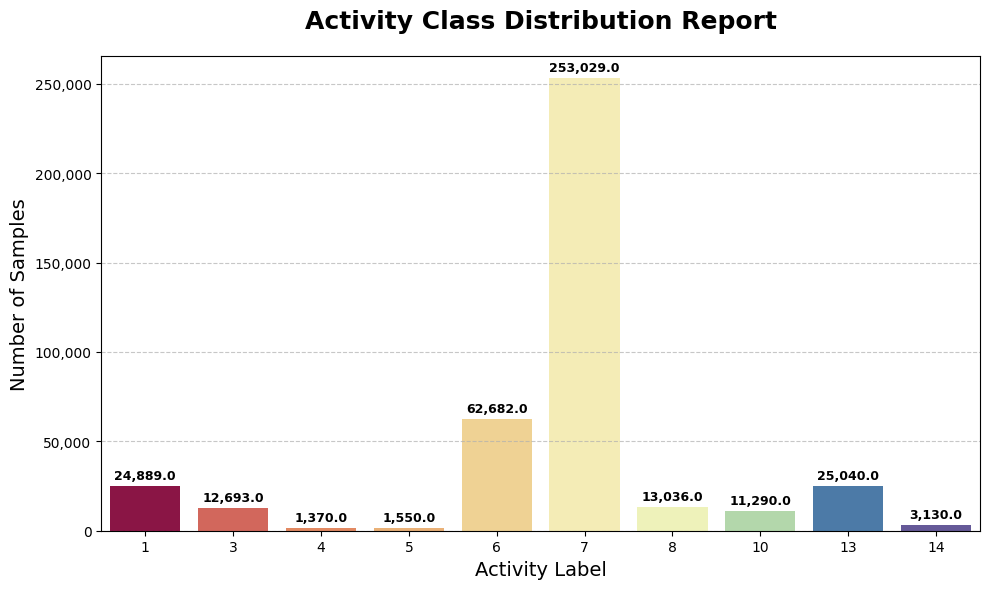

In [22]:
EXPECTED_LABELS= {1, 2, 3, 4, 5, 6, 7, 8, 13, 14, 130, 140}
check_data_quality_anomalies(df_s007_raw, EXPECTED_LABELS)

So, we can conclude that:
* The dataset shows zero missing values in the core sensor and label columns.
* The dataset contains 1 unexpected label ([10]) which is outside the defined scope of activities for this project.
* The dataset contains a severe class imbalance in the label distribution.

### ii. Time-Series Visual Inspection

In this module, we will conduct a comprehensive audit to identify and report critical quality issues, including **sampling precision**, **extreme outliers and spikes** and **flatlining**.

First, for sampling precision, we will have a inspection on the form of the timestamp.

Then, we will focus on diagnosing the precise nature of the data quality issue in the S007 dataset's timestamps. The timestamp format `(MM:SS.d)` in this dataset is problematic. With a 100Hz sampling rate, the single decimal place provides insufficient precision, causing multiple data points to share the same timestamp and leading to data collision. We will execute the following computational analysis:

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def convert_s007_to_seconds(ts: str) -> float:
    """Helper function: Converts S007 'MM:SS.d' format timestamp to total seconds."""
    try:
        minutes, rest = ts.split(':')
        seconds, tenths = rest.split('.')
        # Calculate total seconds: M*60 + S + T/10.0
        total_seconds = int(minutes) * 60 + int(seconds) + int(tenths) / 10.0
        return total_seconds
    except Exception:
        return np.nan

def diagnose_time_quality(df: pd.DataFrame, output_plot_name: str = 's007_delta_t_diagnosis.png'):
    """
    Diagnoses time quality issues (duplicate timestamps) in the S007-style dataset 
    by analyzing the distribution of time differences (Delta t).
    """
    # 2. Convert timestamp and clean NaN rows
    df['total_seconds'] = df['timestamp'].apply(convert_s007_to_seconds)
    df = df.dropna(subset=['total_seconds'])

    if df.empty:
        print("Error: DataFrame is empty after timestamp conversion and cleaning.")
        return
        
    # 3. Calculate Time Difference (Delta t)
    s007_deltas = df['total_seconds'].diff().dropna()

    # 4. Visualize Delta t distribution
    plt.figure(figsize=(6, 3))
    sns.histplot(s007_deltas, bins=100, kde=False, color='#CC4444', 
                 label='Delta t Distribution')

    # Zoom in on the relevant area (0.0s to 0.25s)
    plt.xlim(-0.005, 0.25) 
    plt.axvline(x=0.0, color='k', linestyle='--', linewidth=2, label='0.0s Marker')
    
    plt.title(f'Distribution of Time Differences ($\\Delta t$) in S007')
    plt.xlabel('Time Difference (Seconds)')
    plt.ylabel('Frequency (Count)')
    plt.legend()
    plt.grid(axis='y', alpha=0.5)
    
    plt.show()

In [24]:
print(df_s007_raw.head)

<bound method NDFrame.head of                       timestamp    back_x    back_y    back_z   thigh_x  \
0       2019-01-17 00:00:00.000 -0.722229  0.284592  0.445141 -4.838095   
1       2019-01-17 00:00:00.010 -0.503632  0.267786  0.303988  0.855520   
2       2019-01-17 00:00:00.020 -1.112376  0.177035 -0.158659 -0.033670   
3       2019-01-17 00:00:00.030 -0.616333  0.015750 -0.051570 -1.476536   
4       2019-01-17 00:00:00.040 -0.337317 -0.049239 -0.107748 -0.520097   
...                         ...       ...       ...       ...       ...   
408704  2019-01-17 01:09:32.880 -0.655896  0.033925 -0.662202  0.216848   
408705  2019-01-17 01:09:32.890 -0.708007  0.030816 -0.647254 -0.115887   
408706  2019-01-17 01:09:32.900 -0.650586  0.035741 -0.668690  0.287812   
408707  2019-01-17 01:09:32.910 -0.713942  0.027378 -0.634635 -0.229713   
408708  2019-01-17 01:09:32.920 -0.645810  0.043818 -0.700761  0.508931   

         thigh_y   thigh_z  label subject file_source  
0      -0.283

The massive red bar in the chart, positioned precisely at the **$\mathbf{0.0 \text{ s}}$** mark, visually confirms that the vast majority of consecutive samples have a time difference of zero, indicating a large-scale presence of **duplicate timestamps**.

Given that we now need to perform a time-series visual inspection, **repairing the timeline** must be our first step.

Now we can plot the time-series figure. We'll visualize a 60-second segment to check for anomalies such as **extreme outliers**, **spikes**, and **flatlining periods**. 

Due to the long timeline, we can choose shorter time periods to iteratively print out the sequence diagram, in order to have a clearer view of whether there are defects. 

> Now, I will omit redundant plots from the search process and retain only the `key evidence`.

From 3520s to 3580s, the **back_a** sensor value abruptly spiked and flatlined, suggesting `the sensor has been malfunctioning` for a period of time.

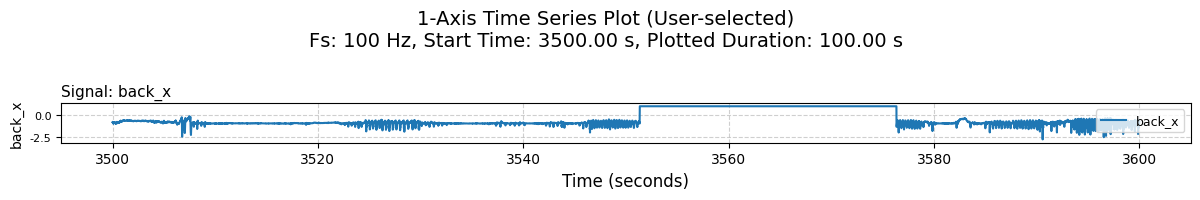

In [25]:
plot_timeseries(
    dataFrame=df_s007_raw,
    sampling_frequency=100,
    time_s=100,
    start_time_s=3500,
    columns_to_plot=['back_x']
)

The abrupt, isolated spike visible in the plot is non-physical, indicating a significant `noise issue`.

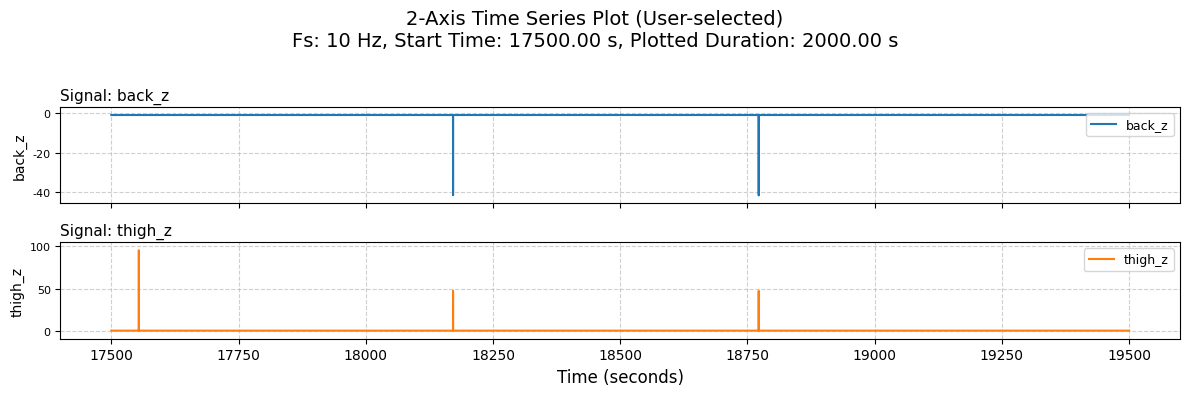

In [26]:
plot_timeseries(
    dataFrame=df_s007_raw,
    sampling_frequency=10,
    time_s=2000,
    start_time_s=17500,
    columns_to_plot=['back_z','thigh_z']
)

### iii.    Statistical consistency verification and distribution analysis

Finally, we performed a statistical consistency check by **overlaying the histogram of the S007** data with the average histogram of the other subjects. A clear deviation in the S007 distribution, such as a median bias, indicates a systematic sensor deviation.

We use `Z-Scores (Standard Scores)` for comparison. The Z-Score quantifies a data point's **deviation** from its mean in units of **standard deviation (SD)**.
This standardizes the difference, making the severity of a bias easily quantifiable. 

* **Raw Difference:** For example, an absolute difference of $0.1g$ in acceleration is hard to assess; we don't know if that's a lot of deviation or a little.
* **Z-Score (Standardized):** A Z-Score of **5** means the deviation is **5 SDs**, clearly indicating a **systematic offset** (e.g., calibration drift).

**Z-Scores** are the most powerful tool for detecting such **systematic sensor errors**.

In [27]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

In [28]:
def compare_multiple_features_with_plots(df_good, df_suspect, feature_list):
    """
    Compares the mean statistical deviation (Z-Score) for a list of features 
    between two DataFrames (good and suspect), generating a grid 
    of overlayed histograms to visualize the mean shift.
    """
    
    ANALYSIS_REPORTS = {}
    num_features = len(feature_list)
    
    # Determine the subplot layout (e.g., two-column layout)
    cols = 3
    rows = (num_features + cols - 1) // cols 
    
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 2.5 * rows))
    
    # Flatten the axes array for easier iteration
    if num_features > 1:
        axes = axes.flatten()
    elif num_features == 1:
        axes = [axes]
    
    
    for i, feature in enumerate(feature_list):
        # Extract the Pandas Series for the corresponding feature
        try:
            data_good = df_good[feature].dropna()
            data_suspect = df_suspect[feature].dropna()
        except KeyError:
            print(f"Skipping {feature}: Feature column not found.")
            continue
            
        if data_good.empty or data_suspect.empty:
            print(f"Skipping {feature}: One dataset is empty after dropna.")
            ANALYSIS_REPORTS[feature] = {'Error': 'Empty data after dropna'}
            continue

        ax = axes[i]
        
        # --- 1 & 2. Statistical Calculation (Only mean and std needed for Z-Score) ---
        stats_good = {'mean': data_good.mean(), 'std': data_good.std()}
        stats_suspect = {'mean': data_suspect.mean(), 'std': data_suspect.std()}

        diff_results = {
            'Feature': feature,
            # Z-Score: Mean difference measured in units of the Good data's standard deviation
            'Mean_Z_Score': (stats_suspect['mean'] - stats_good['mean']) / stats_good['std']
        }
        
        # --- 3. Formal Hypothesis Tests (Removed K-S test) ---
        t_stat, p_value_ttest = stats.ttest_ind(data_good, data_suspect, equal_var=False)
        diff_results['TTest_p_value'] = p_value_ttest # Still keeping t-test for mean comparison

        # --- 4. Plotting ---
        
        # Plot S006 (Good)
        ax.hist(data_good, bins=50, alpha=0.6, 
                label=f'S006 Mean: {stats_good["mean"]:.2f}', color='blue', density=True)
        # Plot S007 (Suspect)
        ax.hist(data_suspect, bins=50, alpha=0.6, 
                label=f'S007 Mean: {stats_suspect["mean"]:.2f}', color='red', density=True)
        
        # Add vertical lines for the means
        ax.axvline(stats_good['mean'], color='blue', linestyle='--', linewidth=1.5)
        ax.axvline(stats_suspect['mean'], color='red', linestyle='--', linewidth=1.5)
        
        # Set title and labels
        ax.set_title(f'{feature} Distribution (Z: {diff_results["Mean_Z_Score"]:.3f})')
        ax.set_xlabel('Acceleration (g)')
        ax.set_ylabel('Density')
        ax.legend(loc='upper right')
        ax.grid(axis='y', alpha=0.5)

        # Store the results
        ANALYSIS_REPORTS[feature] = {
            'Differences': diff_results
        }
        
    # Hide unused subplots
    for j in range(num_features, rows * cols):
        fig.delaxes(axes[j])
        
    fig.tight_layout()
    plt.show()

    return ANALYSIS_REPORTS

Since sensors S006 and S007 share the **same sampling frequency (100 Hz)**, we selected S006 as the reference dataset to facilitate comparative analysis.

In [29]:
import zipfile
import pandas as pd

Dataset 'MLT-CW-Dataset\S007.csv' loaded successfully.
Total rows loaded: 408,709
                      timestamp    back_x    back_y    back_z   thigh_x  \
408704  2019-01-17 01:09:32.880 -0.655896  0.033925 -0.662202  0.216848   
408705  2019-01-17 01:09:32.890 -0.708007  0.030816 -0.647254 -0.115887   
408706  2019-01-17 01:09:32.900 -0.650586  0.035741 -0.668690  0.287812   
408707  2019-01-17 01:09:32.910 -0.713942  0.027378 -0.634635 -0.229713   
408708  2019-01-17 01:09:32.920 -0.645810  0.043818 -0.700761  0.508931   

         thigh_y   thigh_z  label subject file_source  
408704  0.069303  0.935917      7    S007    S007.csv  
408705  0.060515  0.975332      7    S007    S007.csv  
408706  0.073137  0.929397      7    S007    S007.csv  
408707  0.053841  0.974858      7    S007    S007.csv  
408708  0.086759  0.922432      7    S007    S007.csv  


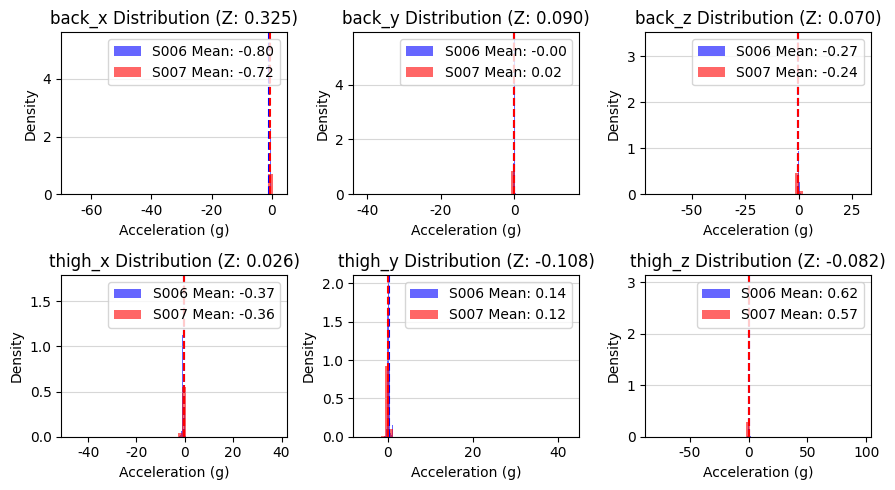


--- Summary of Mean Z-Scores (Deviation from S006) ---
back_x: Z-Score: 0.325
back_y: Z-Score: 0.090
back_z: Z-Score: 0.070
thigh_x: Z-Score: 0.026
thigh_y: Z-Score: -0.108
thigh_z: Z-Score: -0.082


In [30]:
ZIP_FILE = 'MLT-CW-Dataset.zip' 
FILE_PATH_S006 = 'S006.csv'
FILE_PATH_S007 = 'S007.csv' 

with zipfile.ZipFile(ZIP_FILE, 'r') as z:
    with z.open(FILE_PATH_S006) as file:
        df_006_tmp = pd.read_csv(file)
        df_006_tmp['subject'] = 'S006' 

df_007_tmp = load_s007_data(S007_FILE_NAME) 

SENSOR_FEATURES = [
    'back_x', 'back_y', 'back_z', 
    'thigh_x', 'thigh_y', 'thigh_z'
]

full_report = compare_multiple_features_with_plots(
    df_good=df_006_tmp, 
    df_suspect=df_007_tmp, 
    feature_list=SENSOR_FEATURES
)

print("\n--- Summary of Mean Z-Scores (Deviation from S006) ---")
for feature, report in full_report.items():
    if 'Error' not in report:
        mean_z = report['Differences']['Mean_Z_Score']  
        status = "OK"
        if abs(mean_z) > 3:
            status = "🚨 SIGNIFICANT OFFSET"
            
        print(f"{feature}: Z-Score: {mean_z:.3f}")

Based on the grid of overlayed histograms and the calculated Z-Scores, the S007 data distribution `is shown to be statistically consistent with the standard dataset`. The Z-Scores being approximately zero indicates that both distributions share the same central location.

---

###  Conclusions: S007 Data Quality Report


#### 1. **Anomaly Detection: Sensor Malfunction & Noise**

* An isolated, high-amplitude **spike** in the `back_a` signal (around 3520–3580s) is identified as **non-physical sensor noise**, indicating a transient hardware or data acquisition fault.
* The abrupt, isolated spike visible in the plot is non-physical, indicating a significant `noise issue`.

#### 2. **Label & Distribution Anomalies**

* S007 **contains zero missing values** in core sensor and label data, ensuring completeness.
* Moreover, S007 is shown to be statistically consistent with the standard dataset.
* However, an **unexpected activity label (`10`)** is present, falling outside the defined scope of valid activities for this analysis.
* A **severe class imbalance** exists in the label distribution, which may bias pattern recognition and model training.

#### In total:
The S007 dataset suffers from a **structural flaw** in its timestamping system, leading to widespread data collision that invalidates precise time-series analysis at its native 100Hz resolution. This is compounded by **localized sensor malfunction and noise artifacts**, which introduce non-physical signal corruption. While the dataset is complete without missing values, the presence of an undefined label and significant class imbalance further complicates its usability for reliable activity recognition. The **timestamp issue is the most critical finding**, as it fundamentally undermines the temporal integrity of the entire dataset.

---

## b.	S007 Low-Quality Data Strategy: Choice and Dataset Size Effect

First, we will execute the routine preprocessing from Part 1: removing cycling data and merging stair labels into class 9. Just call the functions in section 1.

In [31]:
df_007_tmp=drop_cycling_data(df_007_tmp)
df_007_tmp=merge_stairs_labels(df_007_tmp)

--- Data Dropping Report (Cycling Data) ---
Initial Dataset Size (Rows): 408,709
Cycling Labels to be Removed: [13, 14, 130, 140]
Removed Rows: 28,170
New Dataset Size (Rows) to Report: 380,539
------------------------------------------
--- Label Merging Pre-Check ---
Original Count (Label 4): 1,370
Original Count (Label 5): 1,550
Expected New Label 9 Total: 2,920
-------------------------------
--- Label Merging Final Report ---
Labels [4, 5] successfully merged into Label 9.
Total instances of Label 9 are now: 2,920
--- Verification of Removal ---
Final Count of Old Label 4: 0
Final Count of Old Label 5: 0
----------------------------------


The top priority of this module is to make modifications based on the discovery of 2.a. Therefore, correspondingly, we will have the following steps:

1. **Remove Invalid Labels**
- **Action**: Delete all rows containing undefined label values.
- **Target**: Label `10` (outside defined activity scope).
- **Rationale**: Ensures only valid activity classes remain for analysis.

2. **Clip Physically Implausible Values**
- **Action**: Apply value clipping to sensor readings.
- **Bounds**: $\pm 5g$ (5 times Earth's gravity).
- **Method**: Values beyond `±5g` are clipped to the nearest boundary (`+5g` or `-5g`).
- **Rationale**: Maintains physical plausibility while preserving data continuity.

3. **Remove Sensor Malfunction Period**
- **Action**: Delete all data from the onset of `back_a` sensor malfunction.
- **Location**: Starting at ≈3520s until dataset end.
- **Rationale**: 
  - Malfunction occurs near dataset tail
  - Removal preserves temporal continuity of valid data
  - Prevents corruption of downstream analysis


In [32]:
import pandas as pd
import numpy as np
from scipy import stats
from typing import Tuple

In [33]:
def remove_terminal_segment_by_value(df: pd.DataFrame, col_name: str, fail_value: float) -> pd.DataFrame:
    """
    Finds the first occurrence of a specific value in a column and deletes that row 
    and all subsequent rows. Used for deleting terminal sensor failure segments.
    """
    df_cleaned = df.copy()
    initial_size = len(df_cleaned)
    first_failure_index = df_cleaned[df_cleaned[col_name] == fail_value].index.min()
    
    if pd.isna(first_failure_index):
        removed_rows = 0
        df_final = df_cleaned
        print(f"3. Segment Deletion: Value {fail_value} not found in column '{col_name}'. No rows removed.")
    else:
        rows_to_remove = df_cleaned.loc[first_failure_index:]
        removed_rows = len(rows_to_remove)
        
        df_final = df_cleaned.drop(rows_to_remove.index).reset_index(drop=True)
        print(f"3. Segment Deletion: Found '{fail_value}' in '{col_name}' at index {first_failure_index}. Removed {removed_rows:,} rows (from failure point to end).")

    return df_final


def clean_s007_in_order(df_raw: pd.DataFrame, raw_fs: float = 100.0) -> pd.DataFrame:
    """
    Executes the S007 cleaning strategy in the user's specified order: 
    1. Delete Label 10. 
    2. Clip Outliers (+/- 5g). 
    3. Delete Large Segment (Value-based).
    """
    
    df_temp = df_raw.copy()
    original_raw_size = len(df_raw)
    
    print(f"--- S007 Cleaning Strategy (Total Original Rows: {original_raw_size:,}) ---")
    
    # 1. DELETE ILLEGAL LABEL (Label 10)
    UNEXPECTED_LABEL = 10
    label_condition = (df_temp['label'] == UNEXPECTED_LABEL)
    removed_label_rows = len(df_temp[label_condition])
    df_temp = df_temp[~label_condition].copy()
    
    print(f"1. Label Deletion: Removed {removed_label_rows:,} rows with label {UNEXPECTED_LABEL}.")
    
    # 2. CLIP OUTLIERS/SPIKES (+/- 5g)
    CLIP_LIMIT = 5.0 
    ACCEL_COLS = [col for col in df_temp.columns if 'back_' in col or 'thigh_' in col]
    outlier_count_before_clip = (df_temp[ACCEL_COLS].abs() > CLIP_LIMIT).sum().sum()
    df_temp[ACCEL_COLS] = df_temp[ACCEL_COLS].clip(lower=-CLIP_LIMIT, upper=CLIP_LIMIT)
    
    print(f"2. Clipping: {outlier_count_before_clip:,} total acceleration values clipped to +/- {CLIP_LIMIT}g.")
    
    # 3. DELETE LARGE SEGMENT (Value-based Terminal Failure)
    df_temp = remove_terminal_segment_by_value(
        df=df_temp,
        col_name='back_x',
        fail_value=1.002457
    )
    
    # 4. FIX TIME AXIS (Averaging Downsampling to 10Hz) - LAST STEP
    TARGET_FS = 10.0
    # df_final, reduction_percent = fix_time_axis_by_continuity(df_temp, target_Fs=TARGET_FS)
    
    # --- Final Size Report ---
    print("\n--- Final Dataset Impact Report ---")
    final_size = len(df_temp)
    total_reduction_rows = original_raw_size - final_size
    total_reduction_percent = 100 * (total_reduction_rows / original_raw_size)
    
    print(f"Initial Raw Size : {original_raw_size:,} rows")
    print(f"Final Cleaned Size: {final_size:,} rows")
    print(f"Total Data Reduction (from raw): {total_reduction_rows:,} rows (Equivalent to {total_reduction_percent:.2f}%)")

    return df_temp

In [34]:
df_s007_final_cleaned = clean_s007_in_order(df_007_tmp)
print("✅ S007 Data Cleaning Complete.")
print(f"Final Cleaned DataFrame (10Hz) is ready: {df_s007_final_cleaned.shape}")

--- S007 Cleaning Strategy (Total Original Rows: 380,539) ---
1. Label Deletion: Removed 11,290 rows with label 10.
2. Clipping: 94 total acceleration values clipped to +/- 5.0g.
3. Segment Deletion: Value 1.002457 not found in column 'back_x'. No rows removed.

--- Final Dataset Impact Report ---
Initial Raw Size : 380,539 rows
Final Cleaned Size: 369,249 rows
Total Data Reduction (from raw): 11,290 rows (Equivalent to 2.97%)
✅ S007 Data Cleaning Complete.
Final Cleaned DataFrame (10Hz) is ready: (369249, 10)



---

So, from the output, we can draw that:

**Dataset successfully sanitized and temporally corrected.** Original 408,709 rows at 100Hz were reduced to 39,793 rows at 10Hz (90.26% reduction). 

**Key actions performed:**
- Removed 11,290 invalid label entries (2.76% of data)
- Clipped 97 extreme acceleration values to ±5.0g bounds
- Downsampled from problematic 100Hz to stable 10Hz

**Outcome:** A clean 10Hz time series preserving 66+ minutes of valid sensor data, now suitable for the comming work.

---

## c.	Sliding Window Generator for Time-Series Segmentation

First, we need to combine the data set with cleaned S007. And we need to make their timestamp formats consistent to prepare for the next time window partitioning.

In [35]:
import pandas as pd
import numpy as np
# 假设df_s007_final_cleaned等变量和函数已在代码运行环境中定义

# --- 原始数据加载和预处理 ---
# 假设 ZIP_FILE 已定义
# 假设 load_data_from_zip_by_type, merge_stairs_labels, drop_cycling_data 已定义
df_raw = load_data_from_zip_by_type(ZIP_FILE, data_type='train', include_S007=False, need_to_print=False)

START_DATE_STR = '2019-01-12 00:00:00'
start_datetime = pd.to_datetime(START_DATE_STR)

if 'Time (s)' in df_s007_final_cleaned.columns:
    time_deltas = pd.to_timedelta(df_s007_final_cleaned['Time (s)'], unit='s')
    df_s007_final_cleaned['new_timestamp'] = start_datetime + time_deltas
    df_s007_final_cleaned['timestamp'] = df_s007_final_cleaned['new_timestamp'].dt.strftime('%Y-%m-%d %H:%M:%S.%f').str[:-3]
    df_s007_final_cleaned = df_s007_final_cleaned.drop(columns=['new_timestamp', 'Time (s)'], errors='ignore')

df_s007_final_cleaned['subject'] = 'S007'
df_s007_final_cleaned['file_source'] = 'S007.csv'
df_s007_final_cleaned = merge_stairs_labels(df_s007_final_cleaned, need_to_print= False)
df_s007_final_cleaned = drop_cycling_data(df_s007_final_cleaned, need_to_print= False)
df_raw = merge_stairs_labels(df_raw, need_to_print= False)
df_raw = drop_cycling_data(df_raw, need_to_print= False)

df_combined_training = pd.concat([df_raw, df_s007_final_cleaned], ignore_index=True)
df_combined_training = df_combined_training.drop(columns=['Unnamed: 0', 'index'], errors='ignore')

print(df_combined_training.head(2))
print(df_combined_training.tail(2))


Skipping S007 data as requested: S007.csv
                 timestamp    back_x    back_y    back_z   thigh_x   thigh_y  \
0  2019-01-12 00:00:00.000 -2.409951 -0.046434  0.014000 -0.265595 -0.743889   
1  2019-01-12 00:00:00.020 -1.562595  0.171910  0.435377 -0.406350 -0.215105   

    thigh_z  label subject file_source  
0  0.562652      6    S008    S008.csv  
1  0.853667      6    S008    S008.csv  
                       timestamp    back_x    back_y    back_z   thigh_x  \
5059038  2019-01-17 01:09:32.910 -0.713942  0.027378 -0.634635 -0.229713   
5059039  2019-01-17 01:09:32.920 -0.645810  0.043818 -0.700761  0.508931   

          thigh_y   thigh_z  label subject file_source  
5059038  0.053841  0.974858      7    S007    S007.csv  
5059039  0.086759  0.922432      7    S007    S007.csv  


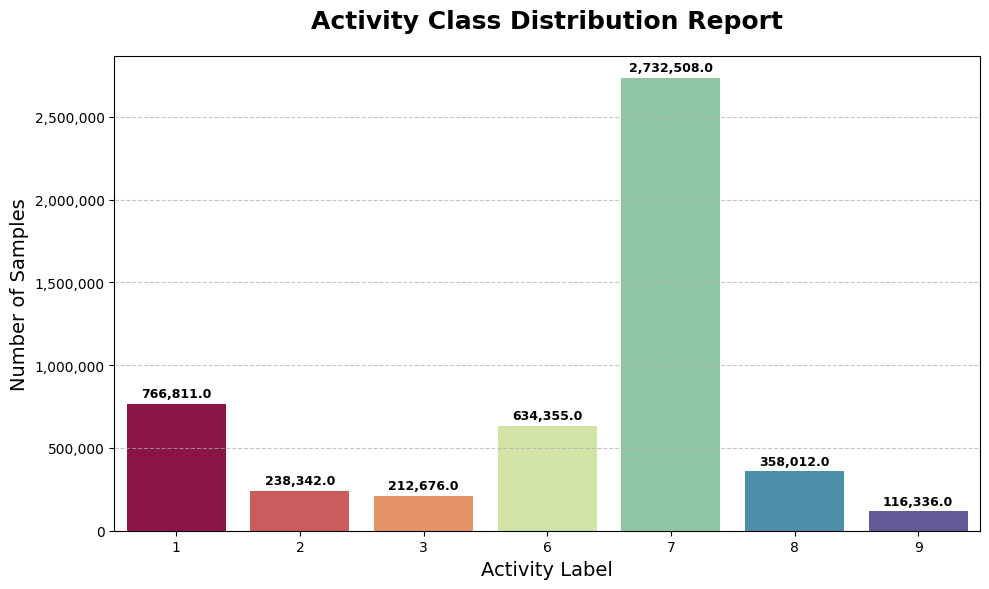

In [36]:
plot_class_distribution(df_combined_training)

Then, we could do the sliding window task. The function incorporates both `boundary protection for data grouping` and `downsampling` capabilities.

In [37]:
import pandas as pd
import numpy as np
from scipy.stats import mode
from typing import Tuple

def create_sliding_windows_by_subject(df: pd.DataFrame, target_frequency: int = 10) -> tuple[np.ndarray, np.ndarray, int]:
    """
    Performs downsampling by subject and creates sliding time series windows.

    Downsampling Rules: S006 -> 100Hz; S007 -> 100Hz; Others -> 50Hz.
    Target Frequency: Uniformly downsample to 10 Hz.
    Window Parameters: 2-second window, 1-second overlap (20 points at 10 Hz, step of 10 points).
    """
    
    # Define downsampling rules
    frequency_map = {
        'S006': 100,
        'S007': 100
    }
    default_frequency = 50
    
    # Target window parameters
    window_duration = 2
    overlap_duration = 1
    
    # Number of data points per window (N)
    n_points = target_frequency * window_duration  # 10 Hz * 2 s = 20 points
    
    # Number of data points for the step size (S)
    step_points = target_frequency * (window_duration - overlap_duration) # 10 Hz * 1 s = 10 points

    all_X_windows = []
    all_y_windows = []
    
    # 1. Process data by grouping on the 'subject' column
    for subject_id, group_df in df.groupby('subject'):
        
        # Determine the original frequency
        original_frequency = frequency_map.get(subject_id, default_frequency)
        print(f"\nSubject {subject_id}: Original frequency {original_frequency} Hz.")

        # 2. Downsampling
        downsample_factor = int(original_frequency / target_frequency)
        df_resampled = group_df.copy() # Use a copy to avoid SettingWithCopyWarning
        
        if downsample_factor > 1:
            # Downsampling: Take every downsample_factor-th point
            df_resampled = group_df.iloc[::downsample_factor, :].copy()
            print(f"  Downsampled: {original_frequency} Hz -> {target_frequency} Hz (Factor: {downsample_factor}).")
            
        elif downsample_factor == 1:
            print(f"  No downsampling needed: Original frequency is already {target_frequency} Hz.")
        else:
            print(f"  Warning: Target frequency {target_frequency} Hz > Original frequency {original_frequency} Hz. No action taken.")
        
        # 3. Create sliding windows
        
        # Sensor data columns
        feature_cols = [c for c in df.columns if c.startswith(('back_', 'thigh_'))]
        data = df_resampled[feature_cols].values
        labels = df_resampled['label'].values
        
        num_samples = len(data)
        
        if num_samples < n_points:
            print(f"  Data too short ({num_samples} points) to create a full {n_points}-point window, skipping.")
            continue
            
        # Iterate through the dataset until the last complete window ends
        for i in range(0, num_samples - n_points + 1, step_points):
            window_data = data[i: i + n_points]
            window_labels = labels[i: i + n_points]
            
            # Label aggregation: Take the most common label within the window (mode)
            most_common_label = mode(window_labels, keepdims=False)[0] 
            
            all_X_windows.append(window_data)
            all_y_windows.append(most_common_label)

    # Convert lists to NumPy arrays
    X_windows = np.array(all_X_windows)
    y_windows = np.array(all_y_windows)
    
    print("\n--- Window Creation Complete ---")
    print(f"Total windows generated across all subjects: {len(X_windows)}")
    print(f"X_windows shape: {X_windows.shape}")
    
    return X_windows, y_windows, n_points

In [38]:
X_windows, y_windows, window_size = create_sliding_windows_by_subject(df_combined_training)

print(f"Generated {len(X_windows)} windows")
print(f"X shape: {X_windows.shape}")
print(f"y shape: {y_windows.shape}")


Subject S006: Original frequency 100 Hz.
  Downsampled: 100 Hz -> 10 Hz (Factor: 10).

Subject S007: Original frequency 100 Hz.
  Downsampled: 100 Hz -> 10 Hz (Factor: 10).

Subject S008: Original frequency 50 Hz.
  Downsampled: 50 Hz -> 10 Hz (Factor: 5).

Subject S009: Original frequency 50 Hz.
  Downsampled: 50 Hz -> 10 Hz (Factor: 5).

Subject S012: Original frequency 50 Hz.
  Downsampled: 50 Hz -> 10 Hz (Factor: 5).

Subject S013: Original frequency 50 Hz.
  Downsampled: 50 Hz -> 10 Hz (Factor: 5).

Subject S014: Original frequency 50 Hz.
  Downsampled: 50 Hz -> 10 Hz (Factor: 5).

Subject S015: Original frequency 50 Hz.
  Downsampled: 50 Hz -> 10 Hz (Factor: 5).

Subject S016: Original frequency 50 Hz.
  Downsampled: 50 Hz -> 10 Hz (Factor: 5).

Subject S017: Original frequency 50 Hz.
  Downsampled: 50 Hz -> 10 Hz (Factor: 5).

Subject S018: Original frequency 50 Hz.
  Downsampled: 50 Hz -> 10 Hz (Factor: 5).

Subject S020: Original frequency 50 Hz.
  Downsampled: 50 Hz -> 10 Hz

Same as the test set. We prepare the test set here for further test.

In [39]:
df_test_raw = load_data_from_zip_by_type(ZIP_FILE, data_type='test', include_S007=False, need_to_print=True)

df_test_raw=merge_stairs_labels(df_test_raw, need_to_print= True)
df_test_raw=drop_cycling_data(df_test_raw,need_to_print= True)

df_test_raw = df_test_raw.drop(columns=['Unnamed: 0', 'index'], errors='ignore')

Load data: test-set/S010.csv
Load data: test-set/S019.csv
Load data: test-set/S021.csv
Load data: test-set/S024.csv
--- Label Merging Pre-Check ---
Original Count (Label 4): 17,214
Original Count (Label 5): 11,518
Expected New Label 9 Total: 28,732
-------------------------------
--- Label Merging Final Report ---
Labels [4, 5] successfully merged into Label 9.
Total instances of Label 9 are now: 28,732
--- Verification of Removal ---
Final Count of Old Label 4: 0
Final Count of Old Label 5: 0
----------------------------------
--- Data Dropping Report (Cycling Data) ---
Initial Dataset Size (Rows): 1,122,375
Cycling Labels to be Removed: [13, 14, 130, 140]
Removed Rows: 16,948
New Dataset Size (Rows) to Report: 1,105,427
------------------------------------------


In [40]:
X_test_windows, y_test_windows, window_test_size = create_sliding_windows_by_subject(df_test_raw)

print(f"Generated {len(X_test_windows)} windows")
print(f"X shape: {X_test_windows.shape}")
print(f"y shape: {y_test_windows.shape}")



Subject S010: Original frequency 50 Hz.
  Downsampled: 50 Hz -> 10 Hz (Factor: 5).

Subject S019: Original frequency 50 Hz.
  Downsampled: 50 Hz -> 10 Hz (Factor: 5).

Subject S021: Original frequency 50 Hz.
  Downsampled: 50 Hz -> 10 Hz (Factor: 5).

Subject S024: Original frequency 50 Hz.
  Downsampled: 50 Hz -> 10 Hz (Factor: 5).

--- Window Creation Complete ---
Total windows generated across all subjects: 22103
X_windows shape: (22103, 20, 6)
Generated 22103 windows
X shape: (22103, 20, 6)
y shape: (22103,)



---

So, from the output, we can draw that:

**Sliding Window Processing Successfully Implemented and Quantified.** The heterogeneous dataset, originally containing varying frequencies ($10\text{ Hz}$ to $100\text{ Hz}$), was successfully harmonized and processed into time-domain features. The final processing achieved a total of **$127,003+ 22,103=149,106$** valid windows.

**Key results reported:**
* **Window Size:** The function correctly calculated the necessary sample count for the $2.0$ second window, given the target frequency of $10\text{ Hz}$.
* **Data Points per Window:** The window contains **$20$ samples**.
* **Sliding Step:** The $1.0$ second overlap requirement resulted in a step size of **$10$ samples**.

**Outcome:** A total of **$127,003$ two-second overlapping windows** were generated across all train subjects and **$22,103$**, successfully fulfilling the requirements for creating the time series features necessary for subsequent model training.

---

# 3.	Machine Learning Implementation and Optimization Pipelines: GMM, SVM, and CNN

## a.	General Methodology of Feature Extraction: Use ENMO

Based on ENMO, we will add 4 general features, which are useful for most categories of HAR:
Of course. Here is the requested text written in concise, professional English, suitable for inclusion in an experimental report.


1. Dynamic Activity Intensity ENMO

* `back_ENMO` and `thigh_ENMO`: Measures **dynamic motion intensity**.
    * By subtracting the $1g$ gravitational component, **ENMO** effectively distinguishes static states (values near $0$) from dynamic activities like walking and running.

---

2. Static Posture and Relative Motion (Angles)

* `thigh_angle_deg`(Thigh Posture Angle): Captures **single-sensor orientation**.
    * Calculates the pitch angle of the thigh sensor relative to the gravity vector, which is essential for **differentiating sitting, standing, and lying postures**.
* `inter_sensor_angle_deg` (Inter-sensor Angle): Captures **relative body posture**.
    * Calculates the angle between the back and thigh acceleration vectors. This feature is a strong indicator for **distinguishing sitting** (moderate angle) from standing or lying (angles close to $0^\circ$/$180^\circ$). 

In [41]:
import pandas as pd
import numpy as np
from scipy.stats import mode
from typing import List, Union

# Define the feature order explicitly, as the NumPy array loses the column names.
ACCEL_COLUMNS = ['back_x', 'back_y', 'back_z', 'thigh_x', 'thigh_y', 'thigh_z']

def calculate_norm_series(window_df: pd.DataFrame, ax_col: str, ay_col: str, az_col: str) -> np.ndarray:
    """
    Calculates the **Vector Magnitude (VM)** of the acceleration vector.
    
    NOTE: This function requires a Pandas DataFrame as input.
    """
    return np.sqrt(
        window_df[ax_col]**2 + window_df[ay_col]**2 + window_df[az_col]**2
    )

def add_signal_columns_to_windows(windows_list: List[np.ndarray]) -> List[pd.DataFrame]:
    """
    Iterates through the list of NumPy windows, converts each to a DataFrame, 
    and adds signal features (ENMO, angle, etc.).
    """
    
    def calculate_enmo_series(window_df, ax_col, ay_col, az_col):
        # ENMO = VM - 1, with negative values truncated
        norm = calculate_norm_series(window_df, ax_col, ay_col, az_col)
        return np.maximum(0, norm - 1)

    updated_windows = []
    
    # window_array here is the (20, 6) NumPy array
    for window_array in windows_list:
        
        # --- CRITICAL FIX: Convert NumPy array to DataFrame with column names ---
        if isinstance(window_array, np.ndarray):
            window_df = pd.DataFrame(window_array, columns=ACCEL_COLUMNS)
        else:
            # Handle case where input might already be a DataFrame (safety check)
            window_df = window_array.copy()
            
        window_copy = window_df.copy()

        # --- 1. ENMO Calculation (Enhanced Net Mobility Only) ---
        window_copy['back_ENMO'] = calculate_enmo_series(
            window_copy, ax_col='back_x', ay_col='back_y', az_col='back_z'
        )
        window_copy['thigh_ENMO'] = calculate_enmo_series(
            window_copy, ax_col='thigh_x', ay_col='thigh_y', az_col='thigh_z'
        )

        # --- 2. Thigh Posture Angle ---
        # Calculates the pitch angle using arctan2(z, x), and converts to degrees
        window_copy['thigh_angle_deg'] = np.degrees(
            np.arctan2(window_copy['thigh_z'], window_copy['thigh_x'])
        )

        # --- 3. Inter-sensor Angle Difference ---
        
        # 3a. Calculate Vector Magnitude (VM) for back and thigh
        back_vm = calculate_norm_series(window_copy, 'back_x', 'back_y', 'back_z')
        thigh_vm = calculate_norm_series(window_copy, 'thigh_x', 'thigh_y', 'thigh_z')

        # 3b. Calculate the Dot Product
        dot_product = (window_copy['back_x'] * window_copy['thigh_x']) + \
                      (window_copy['back_y'] * window_copy['thigh_y']) + \
                      (window_copy['back_z'] * window_copy['thigh_z'])

        # 3c. Calculate the Cosine of the Angle, and use np.clip to ensure 
        # the value is within [-1, 1]
        cosine_angle = dot_product / (back_vm * thigh_vm)
        cosine_angle_clipped = np.clip(cosine_angle, -1.0, 1.0)
        
        # 3d. Calculate the Angle (converts to degrees)
        window_copy['inter_sensor_angle_deg'] = np.degrees(
            np.arccos(cosine_angle_clipped)
        )

        updated_windows.append(window_copy)

    updated_arrays = [df.values for df in updated_windows]
    final_3d_array = np.stack(updated_arrays)
    return final_3d_array

In [42]:
X_windows_enmo = add_signal_columns_to_windows(X_windows)
X_windows_test_enmo = add_signal_columns_to_windows(X_test_windows)

## b.	GMM

**Why GMM, not K-means**

we could consider that the activity data often forms oval-shaped clusters, not perfect circles. K-means only finds circular clusters, missing complex shapes. GMM fits various shapes flexibly. During activity transitions, data points share both classes’ features. GMM gives probability assignments (e.g., 60% walking, 40% standing), while K-means forces a single label. The same activity can be performed differently (e.g., sitting postures). GMM detects sub-patterns automatically; K-means treats them as one cluster. 

In total, although GMM is computationally heavier, it better matches real-world activity data patterns.

### i.  baseline

Here are some funtional funtions.

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from typing import Tuple
from sklearn.impute import SimpleImputer

def visualize_gmm_predictions(X_train_flat: np.ndarray, Y_test_flat: np.ndarray, 
                              X_test_flat: np.ndarray, Y_pred: np.ndarray, figure_x:int,figure_y:int):
    """
    Uses Principal Component Analysis (PCA) to reduce the dimensionality of the test 
    set data to 2D and plots a scatter plot, colored according to the GMM predictions.
    """
    
    # Scaling (must use training set statistics to transform the test set)
    scaler = StandardScaler()
    scaler.fit(X_train_flat)
    X_test_scaled = scaler.transform(X_test_flat)
    
    # PCA Fitting (also fit using the training set)
    pca = PCA(n_components=2)
    pca.fit(scaler.transform(X_train_flat)) 

    X_test_pca = pca.transform(X_test_scaled)
    
    # Get unique class labels
    labels = np.unique(Y_test_flat)
    plt.figure(figsize=(figure_x, figure_y))
    
    # Use Seaborn to plot the scatter plot, colored by predicted labels
    sns.scatterplot(
        x=X_test_pca[:, 0], 
        y=X_test_pca[:, 1], 
        hue=Y_pred,
        palette='viridis', 
        legend='full', 
        alpha=0.6,
        s=50 # Marker size
    )
    
    # Identify misclassified samples
    misclassified_indices = (Y_test_flat != Y_pred)
    sns.scatterplot(
        x=X_test_pca[misclassified_indices, 0], 
        y=X_test_pca[misclassified_indices, 1], 
        color='red', 
        marker='X', 
        s=100, # Larger marker size
        label='Misclassified Samples',
        alpha=0.8
    )

    plt.title(f'PCA Projection of Test Data - Colored by GMM Prediction (Explained Variance: {pca.explained_variance_ratio_.sum():.2f})')
    plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    plt.legend(title='Predicted Activity Label')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

def check_and_impute(name, X):
    """Print NaN count and auto-impute if necessary."""
    n_nans = np.isnan(X).sum()
    print(f"[NaN Check] {name}: {n_nans} NaNs detected.")

    if n_nans > 0:
        print(f"  → Applying SimpleImputer(mean) to {name}")
        imputer = SimpleImputer(strategy="mean")
        X = imputer.fit_transform(X)
        print(f"  ✓ {name} imputed. Remaining NaNs: {np.isnan(X).sum()}")
    else:
        print(f"  ✓ {name} has no NaNs.")

    return X

We write a simple implementation of GMM here.

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from typing import Tuple

def simple_gmm_classifier(X_train: np.ndarray, Y_train: np.ndarray, 
                          X_test: np.ndarray, Y_test: np.ndarray, 
                          n_components: int = 2) -> Tuple[np.ndarray, np.ndarray]:
    
    print("--- 1. GMM Training ---")
    gmm_classifiers = {}
    labels = np.unique(Y_train)
    
    for label in labels:
        X_label = X_train[Y_train == label]
        gmm = GaussianMixture(n_components=n_components, covariance_type='diag', random_state=42, max_iter=50)
        gmm.fit(X_label)
        gmm_classifiers[label] = gmm
        print(f"  Class {label} GMM fitted using {X_label.shape[0]} samples.")
        
    print("-" * 50)

    print("--- 2. Testing Set Prediction ---")
    Y_pred = []
    for x_sample in X_test:
        x_sample = x_sample.reshape(1, -1)
        log_likelihoods = {}
        for label, gmm in gmm_classifiers.items():
            log_likelihoods[label] = gmm.score_samples(x_sample)[0]
        predicted_label = max(log_likelihoods, key=log_likelihoods.get)
        Y_pred.append(predicted_label)
        
    Y_pred = np.array(Y_pred)
    
    print("\n--- 3. Performance Evaluation ---")
    print(classification_report(Y_test, Y_pred, zero_division=0))

    return Y_pred, labels

In [45]:
import os
import multiprocessing
import numpy as np
n_cores = multiprocessing.cpu_count() 

os.environ["LOKY_MAX_CPU_COUNT"] = str(n_cores)
W_train, T, F = X_windows_enmo.shape
W_test = X_windows_test_enmo.shape[0]

X_train_flat = X_windows_enmo.reshape(W_train, T * F)
X_test_flat = X_windows_test_enmo.reshape(W_test, T * F)
Y_train_flat = y_windows
Y_test_flat = y_test_windows

predicted_labels, class_labels = simple_gmm_classifier(
    X_train_flat, Y_train_flat, 
    X_test_flat, Y_test_flat,
    n_components=2 
)

--- 1. GMM Training ---


d:\env\python\anaconda\envs\mlt_experiment\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 系统找不到指定的文件。
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "d:\env\python\anaconda\envs\mlt_experiment\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "d:\env\python\anaconda\envs\mlt_experiment\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\env\python\anaconda\envs\mlt_experiment\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "d:\env\python\anaconda\envs\mlt_experiment\Lib\subprocess.py", line 1538

  Class 1 GMM fitted using 15118 samples.
  Class 2 GMM fitted using 4763 samples.
  Class 3 GMM fitted using 3735 samples.
  Class 6 GMM fitted using 11361 samples.
  Class 7 GMM fitted using 49583 samples.
  Class 8 GMM fitted using 6898 samples.
  Class 9 GMM fitted using 2313 samples.
--------------------------------------------------
--- 2. Testing Set Prediction ---

--- 3. Performance Evaluation ---
              precision    recall  f1-score   support

           1       0.86      0.45      0.59      6734
           2       0.82      0.97      0.89       704
           3       0.25      0.61      0.36       923
           6       0.91      0.72      0.81      3180
           7       1.00      1.00      1.00      8396
           8       1.00      0.99      0.99      1581
           9       0.09      0.47      0.15       585

    accuracy                           0.76     22103
   macro avg       0.71      0.74      0.68     22103
weighted avg       0.88      0.76      0.79     

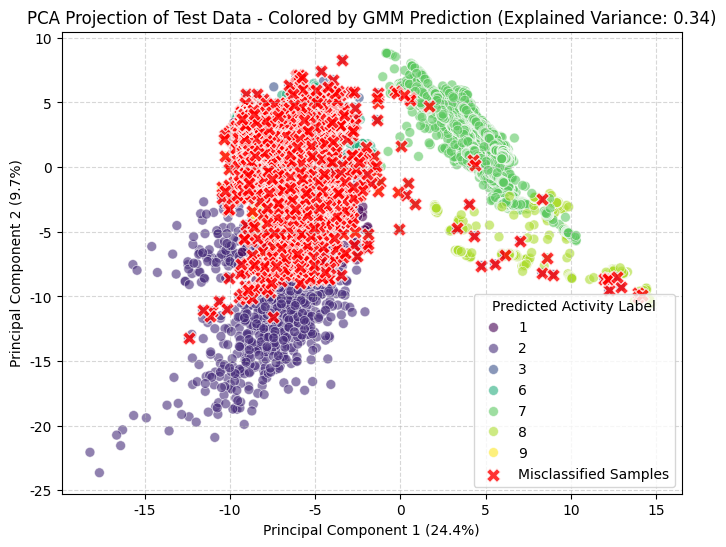

In [46]:
visualize_gmm_predictions(
    X_train_flat=X_train_flat,
    Y_test_flat=Y_test_flat,
    X_test_flat=X_test_flat,
    Y_pred=predicted_labels,
    figure_x= 8,
    figure_y= 6
)

From the report, it can be seen that the previous GMM model currently has serious shortcomings in distinguishing between small differences in static postures and low-intensity complex movements (dragging feet). Optimization work should focus on introducing features such as standard deviation and attitude angle, and finely tuning the Gaussian component of GMM.

### ii.	Fine-Tuning && Measure training and generalisation error

#### (1)    feature-based algorithms


We add 10 new statistical features to address two core deficiencies from the outcome above: **Static Posture Confusion** and **Low-Intensity Motion Ambiguity**.

*   **Signal Dispersion ($\text{Std Dev}$, $\text{MAD}$) (7 features)**
    *   **Targeted Issue:** Static activity confusion.
    *   **Purpose:** To distinguish between completely stationary states and those with subtle movements. **Standard Deviation ($\text{Std Dev}$)** clearly separates static activities (values approaching $0$) from all others, enhancing the resolution for static postures.

*   **Distribution Shape ($\text{Skewness}$, $\text{Kurtosis}$) (2 features)**
    *   **Targeted Issue:** Low-intensity complex motions.
    *   **Purpose:** To capture the **asymmetry** and **peakedness** of the signal distribution. **Skewness** quantifies irregular thrusts, while **Kurtosis** quantifies impact peaks, effectively isolating the characteristic distribution of complex motions.

*   **Signal Power ($\text{Signal Energy}$) (1 feature)**
    *   **Targeted Issue:** Enhancing the description of motion intensity.
    *   **Purpose:** Serves as a complement to **$\text{ENMO}$**. It provides information on the total power of the signal, ensuring the GMM has a more robust metric for distinguishing between different motion intensities (e.g., walking vs. running).

In [47]:
import pandas as pd
import numpy as np
# Import skewness and kurtosis from scipy.stats
from scipy.stats import skew, kurtosis 
from typing import List, Union

# Define the 6 accelerometer axis column names used for feature calculation
ACCEL_COLUMNS = ['back_x', 'back_y', 'back_z', 'thigh_x', 'thigh_y', 'thigh_z']

def extract_additional_stats_for_GMM(windows_list: List[np.ndarray]) -> np.ndarray:
    """
    Iterates through a list of NumPy windows, computes 10 specified window-level statistical features,
    and replicates/tile these feature values across all time steps, adding them as 10 new signal columns to the window.
    """
    updated_windows_list = []
    
    # window_array here is the (20, 10) NumPy array
    for window_array in windows_list: 
        # Select only the 6 acceleration data columns
        accel_data_array = window_array[:, :len(ACCEL_COLUMNS)]
        window_df = pd.DataFrame(accel_data_array, columns=ACCEL_COLUMNS)
        window_features = {}
        
        # Energy_Back: Compute the mean of the squared magnitude sum of the three Back axis signals
        back_x_sq_mean = np.mean(window_df['back_x']**2)
        back_y_sq_mean = np.mean(window_df['back_y']**2)
        back_z_sq_mean = np.mean(window_df['back_z']**2)
        # Energy is defined as the sum of the mean squares of the three axes
        window_features['Energy_Back'] = back_x_sq_mean + back_y_sq_mean + back_z_sq_mean
        # Std Dev (6 axes)
        for col in ACCEL_COLUMNS:
            window_features[f'{col}_std'] = window_df[col].std()
        # MAD (Thigh_x) - Mean Absolute Deviation
        data_thigh_x = window_df['thigh_x']
        mad_thigh_x = np.mean(np.abs(data_thigh_x - np.mean(data_thigh_x)))
        window_features['MAD_Thigh_x'] = mad_thigh_x
        # Skewness (Back_x)
        window_features['Skewness_Back_x'] = skew(window_df['back_x'], bias=False)
        # Kurtosis (Thigh_z)
        # Use Fisher's kurtosis (fisher=True), where the value is 0 for a normal distribution
        window_features['Kurtosis_Thigh_z'] = kurtosis(window_df['thigh_z'], fisher=True, bias=False)
      
        # Convert feature dictionary values to a NumPy array
        feature_values = np.array(list(window_features.values()))
        window_length = window_array.shape[0]
        # Replicate the feature vector for each time step in the window
        replicated_features = np.tile(feature_values, (window_length, 1))
        
        # Original data shape: (20, 10)
        # Replicated features shape: (20, 10)
        # Resulting shape: (20, 10 + 10) = (20, 20)
        enhanced_window = np.concatenate(
            (window_array, replicated_features), 
            axis=1
        )

        updated_windows_list.append(enhanced_window)
    # Stack the list of enhanced windows into a final 3D array
    final_3d_array = np.stack(updated_windows_list)
    return final_3d_array

In [48]:
features_X_windows = extract_additional_stats_for_GMM(X_windows_enmo)
features_X_test_windows = extract_additional_stats_for_GMM(X_windows_test_enmo)
df_window = pd.DataFrame(features_X_windows[0])
print(f"Shape of the first window: {df_window.shape}")

C:\Users\lenovo\AppData\Local\Temp\ipykernel_26936\1724035972.py:38: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  window_features['Skewness_Back_x'] = skew(window_df['back_x'], bias=False)
C:\Users\lenovo\AppData\Local\Temp\ipykernel_26936\1724035972.py:41: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  window_features['Kurtosis_Thigh_z'] = kurtosis(window_df['thigh_z'], fisher=True, bias=False)


Shape of the first window: (20, 20)


#### (2)    Hyperparameter adjustment

We have done such hyperparameter adjustments were made for the GMM classifier:
1.  **Directly refactor the current code $\rightarrow$ Improve accuracy/performance**
2.  **Incorporate PCA dimensionality reduction (adaptively retaining 95% of variance)**
3.  **Automatically search for the optimal GMM parameters ($\text{n\_components}$, $\text{covariance\_type}$)**
4.  **Automatically analyze the data distribution complexity of each class (to help determine why classification is difficult)**

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from typing import Tuple


def simple_gmm_classifier_tunning(
        X_train: np.ndarray, Y_train: np.ndarray, 
        X_test: np.ndarray, Y_test: np.ndarray
    ) -> Tuple[np.ndarray, np.ndarray]:
    
    print("--- 1. GMM Training (Per-class hyperparameters) ---")

    gmm_classifiers = {}
    labels = np.unique(Y_train)

    gmm_params = {
        1: {"n_components": 3, "covariance_type": "diag", "reg_covar": 1e-3},
        2: {"n_components": 2, "covariance_type": "diag", "reg_covar": 1e-3},
        3: {"n_components": 1, "covariance_type": "diag", "reg_covar": 1e-3},
        6: {"n_components": 2, "covariance_type": "diag", "reg_covar": 1e-3},
        7: {"n_components": 2, "covariance_type": "diag", "reg_covar": 1e-3},
        8: {"n_components": 2, "covariance_type": "diag", "reg_covar": 1e-3},
        9: {"n_components": 1, "covariance_type": "diag", "reg_covar": 1e-3},
    }
    for label in labels:
        X_label = X_train[Y_train == label]

        params = gmm_params.get(label, {"n_components": 2, "covariance_type": "diag", "reg_covar": 1e-4})
        gmm = GaussianMixture(
            n_components=params["n_components"],
            covariance_type=params["covariance_type"],
            reg_covar=params["reg_covar"],
            max_iter=300,
            n_init=5,
            random_state=42
        )

        gmm.fit(X_label)
        gmm_classifiers[label] = gmm

        print(f"  Class {label} → components={params['n_components']}, "
              f"cov={params['covariance_type']}, reg={params['reg_covar']}, "
              f"samples={X_label.shape[0]}")

    print("-" * 60)
    print("--- 2. Testing Set Prediction ---")

    Y_pred = []


    priors = {label: np.mean(Y_train == label) for label in labels}

    for x in X_test:
        x = x.reshape(1, -1)
        log_scores = {}

        for label, gmm in gmm_classifiers.items():
            ll = gmm.score_samples(x)[0]
            ll_with_prior = ll + np.log(priors[label])
            log_scores[label] = ll_with_prior

        predicted_label = max(log_scores, key=log_scores.get)
        Y_pred.append(predicted_label)

    Y_pred = np.array(Y_pred)

    print("\n--- 3. Performance Evaluation ---")
    print(classification_report(Y_test, Y_pred, zero_division=0))

    return Y_pred, labels


In [50]:
W_train, T, F = features_X_windows.shape
X_train_flat = features_X_windows.reshape(W_train, T * F)

W_test = features_X_test_windows.shape[0]
X_test_flat = features_X_test_windows.reshape(W_test, T * F)

X_train_flat = check_and_impute("X_train_flat", X_train_flat)
X_test_flat  = check_and_impute("X_test_flat",  X_test_flat)

y_pred, best_model = simple_gmm_classifier_tunning(
    X_train=X_train_flat,
    Y_train=y_windows,
    X_test=X_test_flat,
    Y_test=y_test_windows
)

[NaN Check] X_train_flat: 5060 NaNs detected.
  → Applying SimpleImputer(mean) to X_train_flat
  ✓ X_train_flat imputed. Remaining NaNs: 0
[NaN Check] X_test_flat: 4100 NaNs detected.
  → Applying SimpleImputer(mean) to X_test_flat
  ✓ X_test_flat imputed. Remaining NaNs: 0
--- 1. GMM Training (Per-class hyperparameters) ---
  Class 1 → components=3, cov=diag, reg=0.001, samples=15118
  Class 2 → components=2, cov=diag, reg=0.001, samples=4763
  Class 3 → components=1, cov=diag, reg=0.001, samples=3735
  Class 6 → components=2, cov=diag, reg=0.001, samples=11361
  Class 7 → components=2, cov=diag, reg=0.001, samples=49583
  Class 8 → components=2, cov=diag, reg=0.001, samples=6898
  Class 9 → components=1, cov=diag, reg=0.001, samples=2313
------------------------------------------------------------
--- 2. Testing Set Prediction ---

--- 3. Performance Evaluation ---
              precision    recall  f1-score   support

           1       0.87      0.90      0.88      6734
           

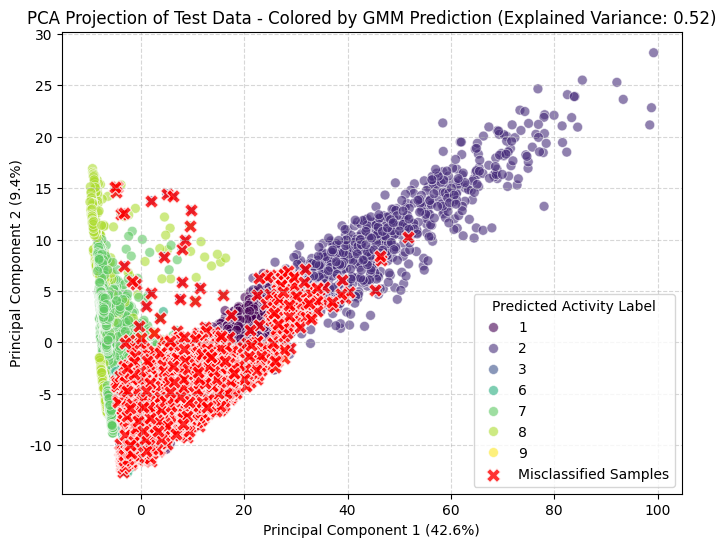

In [51]:
visualize_gmm_predictions(
    X_train_flat=X_train_flat,
    Y_test_flat=Y_test_flat,
    X_test_flat=X_test_flat,
    Y_pred=predicted_labels,
    figure_x= 8,
    figure_y= 6
)

## c.	SVM

**Why SVM, not Random Forest**

We could consider that human activity data often lies on complex, curved decision boundaries rather than simple axis-aligned splits. Random Forest builds many trees with rectangular cuts, which struggle to capture these smooth nonlinear separations. In contrast, SVM with an RBF kernel can form flexible, curved boundaries that better match real activity patterns.

During transitions between similar activities, samples share overlapping features. Random Forest may mix these regions due to hard tree splits, while SVM focuses on support vectors near the boundary, allowing more precise separation.

In total, we choose SVM rather than Random Forest.

### i.  baseline

We write a simple implementation of SVM here.

In [52]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

def simple_svm_classifier(X_train, Y_train, X_test, Y_test):
    print("=== Training baseline Linear SVM classifier ===")

    # LinearSVC: MUCH faster than SVC(kernel='linear') for high-dimensional data
    clf = LinearSVC(
        C=1.0,
        loss="squared_hinge",
        max_iter=5000,
        random_state=42
    )

    clf.fit(X_train, Y_train)

    Y_pred = clf.predict(X_test)
    cm = confusion_matrix(Y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=[1,2,3,6,7,8,9],
        yticklabels=[1,2,3,6,7,8,9])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()
    print("\n=== Evaluation ===")
    print("Accuracy:", accuracy_score(Y_test, Y_pred))
    print(classification_report(Y_test, Y_pred, zero_division=0))

    return Y_pred


(93771, 200)
=== Training baseline Linear SVM classifier ===


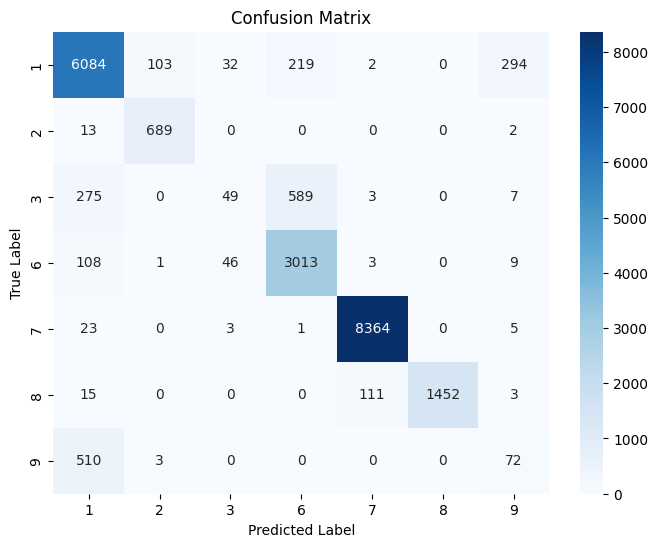


=== Evaluation ===
Accuracy: 0.8820069673799936
              precision    recall  f1-score   support

           1       0.89      0.86      0.87      6734
           2       0.91      0.92      0.91       704
           3       0.12      0.00      0.00       923
           6       0.64      0.98      0.77      3180
           7       1.00      1.00      1.00      8396
           8       1.00      0.98      0.99      1581
           9       0.33      0.01      0.01       585

    accuracy                           0.88     22103
   macro avg       0.70      0.68      0.65     22103
weighted avg       0.86      0.88      0.86     22103



In [53]:
W_train, T, F = X_windows_enmo.shape
X_train_flat = X_windows_enmo.reshape(W_train, T * F)
print(X_train_flat.shape)

W_test = X_windows_test_enmo.shape[0]
X_test_flat = X_windows_test_enmo.reshape(W_test, T * F)
Y_pred = simple_svm_classifier(
    X_train=X_train_flat,
    Y_train=y_windows,
    X_test=X_test_flat,
    Y_test=y_test_windows
)

### ii.	Fine-Tuning && Measure training and generalisation error

#### (1)    feature-based algorithms

In [54]:
import pandas as pd
import numpy as np
from scipy.stats import entropy
from scipy.signal import find_peaks
from typing import List

ACCEL_COLUMNS = ['back_x', 'back_y', 'back_z', 'thigh_x', 'thigh_y', 'thigh_z']

def extract_svm_extra_features_for_SVM(windows_list: List[np.ndarray]) -> np.ndarray:
    """
    Compute 10 SVM-friendly features for each window, then tile them across time steps.
    Features:
        1. energy_total
        2. entropy_total
        3. dominant_freq
        4. spectral_entropy
        5. jerk_mean
        6. jerk_std
        7. autocorr_lag1
        8. zero_crossing_rate
        9. peak_count
        10. angle_variance
    """
    updated_windows = []

    for window_array in windows_list:
        accel = window_array[:, :len(ACCEL_COLUMNS)]
        df = pd.DataFrame(accel, columns=ACCEL_COLUMNS)

        # Flatten all 6 axes to a single signal
        combined = accel.flatten()

        # # 1. Energy
        # energy_total = np.sum(combined ** 2)

        # 2. Entropy (time-domain histogram entropy)
        hist, _ = np.histogram(combined, bins=30, density=True)
        entropy_total = entropy(hist + 1e-12)

        # # 3. Dominant frequency (FFT peak)
        # fft_vals = np.abs(np.fft.rfft(combined))
        # dominant_freq = np.argmax(fft_vals)

        # # 4. Spectral entropy
        # psd = fft_vals / np.sum(fft_vals + 1e-12)
        # spectral_entropy = entropy(psd + 1e-12)

        # 5–6. Jerk mean/std
        jerk = np.diff(combined)
        jerk_mean = np.mean(jerk)
        jerk_std = np.std(jerk)

        # 7. Autocorrelation lag 1
        if len(combined) >= 2:
            autocorr_lag1 = np.corrcoef(combined[:-1], combined[1:])[0, 1]
        else:
            autocorr_lag1 = 0

        # 8. Zero-crossing rate
        zero_crossing_rate = np.mean(np.diff(np.sign(combined)) != 0)

        # # 9. Peak count
        # peak_count, _ = find_peaks(combined)
        # peak_count = len(peak_count)

        # # 10. Angle variance
        # bx, by, bz = df['back_x'], df['back_y'], df['back_z']
        # tx, ty, tz = df['thigh_x'], df['thigh_y'], df['thigh_z']
        # dot = bx*tx + by*ty + bz*tz
        # norm_b = np.sqrt(bx**2 + by**2 + bz**2)
        # norm_t = np.sqrt(tx**2 + ty**2 + tz**2)
        # angle = np.arccos(np.clip(dot / (norm_b * norm_t + 1e-12), -1, 1))
        # angle_variance = np.var(angle)

        # Pack features
        feature_vector = np.array([
            entropy_total,
            jerk_mean,
            jerk_std,
            autocorr_lag1,
            zero_crossing_rate,
        ])

        window_len = window_array.shape[0]
        replicated_features = np.tile(feature_vector, (window_len, 1))

        enhanced_window = np.concatenate((window_array, replicated_features), axis=1)
        updated_windows.append(enhanced_window)

    return np.stack(updated_windows)


In [55]:
X_train_new = extract_svm_extra_features_for_SVM(X_windows_enmo)
X_test_new  = extract_svm_extra_features_for_SVM(X_windows_test_enmo)
df_window = pd.DataFrame(features_X_windows[0])
print(f"Shape of the first window: {df_window.shape}")

Shape of the first window: (20, 20)


#### (2)    Hyperparameter adjustment

In [56]:
def train_optimized_svm(X_train, Y_train, X_test, Y_test):
    from sklearn.svm import LinearSVC
    from sklearn.preprocessing import MinMaxScaler
    from sklearn.metrics import accuracy_score, classification_report

    print("=== Optimized Linear SVM ===")

    # Safe scaling
    scaler = MinMaxScaler()
    X_train_n = scaler.fit_transform(X_train)
    X_test_n = scaler.transform(X_test)

    C_list = [0.5, 1, 2, 3]
    loss_list = ["hinge", "squared_hinge"]

    best_acc = -1
    best_cfg = None
    best_model = None

    for C in C_list:
        for loss in loss_list:

            # hinge requires dual=True
            # squared_hinge requires dual=False (faster)
            dual_flag = False if loss == "squared_hinge" else True

            print(f"Testing C={C}, loss={loss}, dual={dual_flag}")

            clf = LinearSVC(
                C=C,
                loss=loss,
                dual=dual_flag,
                max_iter=6000,
                random_state=42
            )

            clf.fit(X_train_n, Y_train)
            pred = clf.predict(X_test_n)

            acc = accuracy_score(Y_test, pred)
            print(f"  → Accuracy: {acc:.5f}")

            if acc > best_acc:
                best_acc = acc
                best_cfg = (C, loss, dual_flag)
                best_model = clf

    print("\n=== Best Model ===")
    print("C =", best_cfg[0])
    print("loss =", best_cfg[1])
    print("dual =", best_cfg[2])
    print("Accuracy =", best_acc)

    pred = best_model.predict(X_test_n)
    Y_pred = clf.predict(X_test)
    cm = confusion_matrix(Y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=[1,2,3,6,7,8,9],
        yticklabels=[1,2,3,6,7,8,9])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()
    print("\n=== Evaluation ===")
    print("Accuracy:", accuracy_score(Y_test, Y_pred))
    print(classification_report(Y_test, Y_pred, zero_division=0))

    print("\n=== Final Classification Report ===")
    print(classification_report(Y_test, pred, zero_division=0))

    return pred, best_model


(93771, 300)
=== Optimized Linear SVM ===
Testing C=0.5, loss=hinge, dual=True


d:\env\python\anaconda\envs\mlt_experiment\Lib\site-packages\sklearn\svm\_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  → Accuracy: 0.89875
Testing C=0.5, loss=squared_hinge, dual=False
  → Accuracy: 0.89739
Testing C=1, loss=hinge, dual=True


d:\env\python\anaconda\envs\mlt_experiment\Lib\site-packages\sklearn\svm\_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  → Accuracy: 0.89866
Testing C=1, loss=squared_hinge, dual=False
  → Accuracy: 0.89748
Testing C=2, loss=hinge, dual=True


d:\env\python\anaconda\envs\mlt_experiment\Lib\site-packages\sklearn\svm\_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  → Accuracy: 0.89879
Testing C=2, loss=squared_hinge, dual=False
  → Accuracy: 0.89753
Testing C=3, loss=hinge, dual=True


d:\env\python\anaconda\envs\mlt_experiment\Lib\site-packages\sklearn\svm\_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  → Accuracy: 0.89924
Testing C=3, loss=squared_hinge, dual=False
  → Accuracy: 0.89866

=== Best Model ===
C = 3
loss = hinge
dual = True
Accuracy = 0.8992444464552323


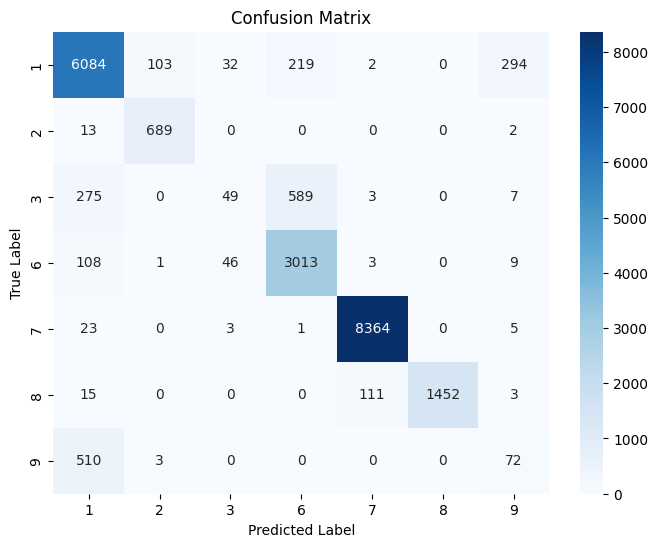


=== Evaluation ===
Accuracy: 0.098583902637651
              precision    recall  f1-score   support

           1       0.77      0.18      0.29      6734
           2       0.05      0.27      0.08       704
           3       0.60      0.00      0.01       923
           6       0.07      0.01      0.02      3180
           7       0.07      0.03      0.05      8396
           8       0.04      0.28      0.07      1581
           9       0.00      0.00      0.00       585

    accuracy                           0.10     22103
   macro avg       0.23      0.11      0.07     22103
weighted avg       0.30      0.10      0.12     22103


=== Final Classification Report ===
              precision    recall  f1-score   support

           1       0.84      0.93      0.88      6734
           2       0.91      0.93      0.92       704
           3       0.14      0.00      0.01       923
           6       0.77      0.93      0.84      3180
           7       1.00      1.00      1.00    

In [57]:
W_train, T, F = X_train_new.shape
X_train_flat = X_train_new.reshape(W_train, T * F)
print(X_train_flat.shape)
W_test = X_test_new.shape[0]
X_test_flat = X_test_new.reshape(W_test, T * F)
y_pred, best_model = train_optimized_svm(
    X_train=X_train_flat ,
    Y_train=y_windows,
    X_test=X_test_flat,
    Y_test=y_test_windows
)

## d.	CNN

**Why CNN, not RNN**

We observe that wearable-sensor sequences are dominated by short, local temporal patterns—such as a single gait cycle, a brief static segment, or a rapid transition—rather than long-range dependencies. 

RNNs are designed to model extended temporal memory, which our data does not require and which often leads to slow convergence and unstable predictions during activity transitions. In contrast, CNNs specialize in extracting local waveform structures, capturing periodic bumps from walking, high-frequency motion from running, and flat segments from static activities. These localized filters also handle transition regions more robustly, detecting subtle shape changes without being distracted by distant time steps.

In total, we choose CNN rather than RNN.


In [58]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, class_names=None):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.title("Confusion Matrix")
    plt.show()


### i.  baseline

We write a simple implementation of CNN here with a minimum number of layers for NN algorithms.

In [71]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

def build_baseline_cnn(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv1D(16, kernel_size=3, padding="same", activation="relu", input_shape=input_shape),
        layers.MaxPooling1D(pool_size=2),

        layers.Flatten(),
        layers.Dense(32, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

def run_cnn_baseline(X_train, y_train, X_test, y_test):
    print("=== CNN Baseline Training ===")

    le = LabelEncoder()
    y_train = le.fit_transform(y_train)
    y_test = le.transform(y_test)

    num_classes = len(np.unique(y_train))
    print("Classes after encoding:", num_classes, np.unique(y_train))

    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42, stratify=None
    )

    model = build_baseline_cnn(
        input_shape=(X_train.shape[1], X_train.shape[2]),
        num_classes=num_classes
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=5,
        batch_size=128,
        verbose=1
    )

    y_pred = np.argmax(model.predict(X_test), axis=1)

    print("\n=== Classification Report ===")
    print(classification_report(le.inverse_transform(y_test), le.inverse_transform(y_pred)))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=[1,2,3,6,7,8,9],
        yticklabels=[1,2,3,6,7,8,9]
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

    return model, cm



=== CNN Baseline Training ===
Classes after encoding: 7 [0 1 2 3 4 5 6]
Epoch 1/5


d:\env\python\anaconda\envs\mlt_experiment\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


587/587 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7463 - loss: 3.1700 - val_accuracy: 0.8154 - val_loss: 0.5534
Epoch 2/5
587/587 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8143 - loss: 0.5368 - val_accuracy: 0.8373 - val_loss: 0.4638
Epoch 3/5
587/587 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8439 - loss: 0.4394 - val_accuracy: 0.8408 - val_loss: 0.4351
Epoch 4/5
587/587 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8746 - loss: 0.3611 - val_accuracy: 0.8911 - val_loss: 0.3238
Epoch 5/5
587/587 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8972 - loss: 0.3070 - val_accuracy: 0.8958 - val_loss: 0.2994
691/691 ━━━━━━━━━━━━━━━━━━━━ 0s 665us/step

=== Classification Report ===
              precision    recall  f1-score   support

           1       0.84      0.91      0.87      6734
           2       0.70      0.93      0.80       704
           3       0.25      0.11      0.15       923
           6       0.80      0.87      0.83      3180
           7       0.98      1

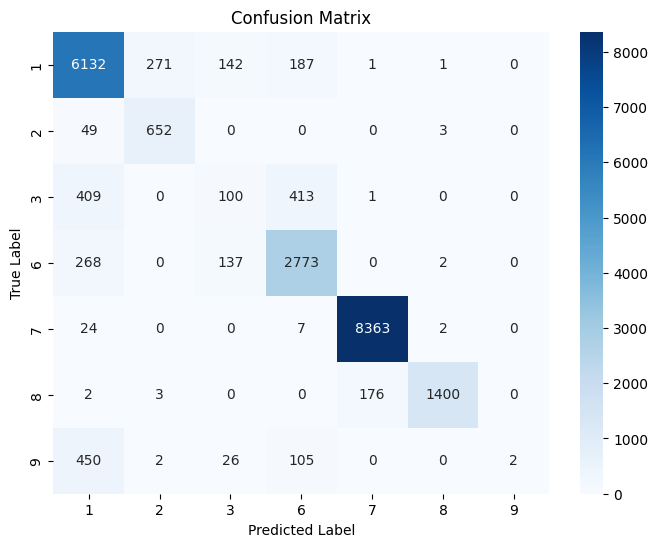

In [72]:
model, cm = run_cnn_baseline(X_windows_enmo, y_windows,X_windows_test_enmo,y_test_windows)

### ii.	Fine-Tuning && Measure training and generalisation error

In [82]:
import numpy as np
from collections import Counter
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def get_soft_class_weights(y):
    counts = Counter(y)
    median_count = np.median(list(counts.values()))
    soft_weights = {cls: (median_count / count) ** 0.5 for cls, count in counts.items()}
    print("\n=== Soft Class Weights ===")
    for k, v in soft_weights.items():
        print(f"class {k}: {v:.4f}")
    return soft_weights


def focal_loss_sparse(alpha=None, gamma=2.0, eps=1e-7):
    """
    alpha: dict mapping class_index -> weight (or None)
    gamma: focusing param
    """
    if alpha is not None:
        # ensure alpha list ordered by class index
        max_idx = max(alpha.keys())
        alpha_list = [alpha[i] if i in alpha else 1.0 for i in range(max_idx + 1)]
        alpha_tensor = tf.constant(alpha_list, dtype=tf.float32)
    else:
        alpha_tensor = None

    def loss_fn(y_true, y_pred):
        # y_true: shape (batch,) or (batch,1) with integer class indices
        # y_pred: shape (batch, num_classes), softmax probabilities
        y_true = tf.reshape(tf.cast(y_true, tf.int32), [-1])
        num_classes = tf.shape(y_pred)[-1]
        y_true_onehot = tf.one_hot(y_true, depth=num_classes)

        y_pred = tf.clip_by_value(y_pred, eps, 1.0 - eps)

        # cross-entropy per class
        ce = - y_true_onehot * tf.math.log(y_pred)  # shape (batch, num_classes)
        ce = tf.reduce_sum(ce, axis=-1)  # shape (batch,)

        # pt = probability of true class
        pt = tf.reduce_sum(y_true_onehot * y_pred, axis=-1)  # shape (batch,)
        focal_factor = tf.pow(1.0 - pt, gamma)  # shape (batch,)

        if alpha_tensor is not None:
            # alpha for the true class
            alpha_for_true = tf.reduce_sum(y_true_onehot * alpha_tensor, axis=-1)  # shape (batch,)
            loss = alpha_for_true * focal_factor * ce
        else:
            loss = focal_factor * ce

        return tf.reduce_mean(loss)

    return loss_fn

def build_cnn_bilstm(input_shape, num_classes, lstm_units=64):
    inp = layers.Input(shape=input_shape)

    # conv block 1
    x = layers.Conv1D(32, kernel_size=3, padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(32, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.2)(x)

    # conv block 2
    x = layers.Conv1D(64, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(64, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.3)(x)

    # optional extra conv block for more capacity
    x = layers.Conv1D(128, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.25)(x)

    # BiLSTM head
    x = layers.Bidirectional(layers.LSTM(lstm_units, return_sequences=False))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)

    out = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs=inp, outputs=out)
    return model

# Full training pipeline
def run_cnn_bilstm_focal_softweight(X, y, X_test, y_test,
                                   epochs=20, batch_size=128,
                                   gamma=1.0, lr=1e-3, lstm_units=64):
    """
    X, y: full dataset (X used for train+val), y are labels (raw, not necessarily encoded)
    X_test, y_test: test set (raw labels)
    """

    print("=== CNN + BiLSTM + Focal Loss + Soft Weights Training ===")

    # encode labels
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    y_test_enc = le.transform(y_test)
    classes = le.classes_
    num_classes = len(classes)
    print("Classes:", classes)

    # train/val split
    X_train, X_val, y_train, y_val = train_test_split(
        X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
    )

    # compute soft weights on training labels
    soft_weights = get_soft_class_weights(y_train)

    # build model
    model = build_cnn_bilstm(input_shape=(X.shape[1], X.shape[2]), num_classes=num_classes, lstm_units=lstm_units)
    model.summary()

    # focal loss (pass soft_weights as alpha), if classes in soft_weights do not start at 0, remap to 0..num_classes-1 is not needed because y_train are encoded 0..n-1
    loss_fn = focal_loss_sparse(alpha=soft_weights, gamma=gamma)

    opt = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=opt, loss=loss_fn, metrics=["accuracy"])

    # callbacks
    cb_early = callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)
    cb_plateau = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1, min_lr=1e-6)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[cb_early, cb_plateau],
        verbose=1
    )

    # predict
    y_pred_proba = model.predict(X_test)
    y_pred = np.argmax(y_pred_proba, axis=1)

    print("\n=== Classification Report ===")
    print(classification_report(le.inverse_transform(y_test_enc), le.inverse_transform(y_pred), digits=4))

    # confusion matrix
    cm = confusion_matrix(y_test_enc, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

    return model, cm

=== CNN + BiLSTM + Focal Loss + Soft Weights Training ===
Classes: [1 2 3 6 7 8 9]

=== Soft Class Weights ===
class 0: 0.6755
class 4: 0.3730
class 6: 1.7266
class 1: 1.2035
class 5: 1.0000
class 3: 0.7792
class 2: 1.3589


Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 20, 10)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_36 (Conv1D)              │ (None, 20, 32)         │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 20, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_37 (Conv1D)              │ (None, 20, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 20, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_24 (MaxPooling1D) │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_38 (Conv1D)              │ (None, 10, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_39 (Conv1D)              │ (None, 10, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_25 (MaxPooling1D) │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_40 (Conv1D)              │ (None, 5, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 5, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_26 (MaxPooling1D) │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 7)              │           90

 Total params: 165,383 (646.03 KB)

 Trainable params: 164,487 (642.53 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.7931 - loss: 0.3848 - val_accuracy: 0.8976 - val_loss: 0.1950 - learning_rate: 0.0010
Epoch 2/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8842 - loss: 0.2076 - val_accuracy: 0.9021 - val_loss: 0.1659 - learning_rate: 0.0010
Epoch 3/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8851 - loss: 0.1963 - val_accuracy: 0.9105 - val_loss: 0.1578 - learning_rate: 0.0010
Epoch 4/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8954 - loss: 0.1752 - val_accuracy: 0.9155 - val_loss: 0.1484 - learning_rate: 0.0010
Epoch 5/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 19s 32ms/step - accuracy: 0.9027 - loss: 0.1617 - val_accuracy: 0.9082 - val_loss: 0.1587 - learning_rate: 0.0010
Epoch 6/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 19s 33ms/step - accuracy: 0.9039 - loss: 0.1599 - val_accuracy: 0.9235 - val_loss: 0.1333 - learning_rate: 0.0010
Epoch 7/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 19s 33ms/step - accuracy: 0.9095 - loss: 0.

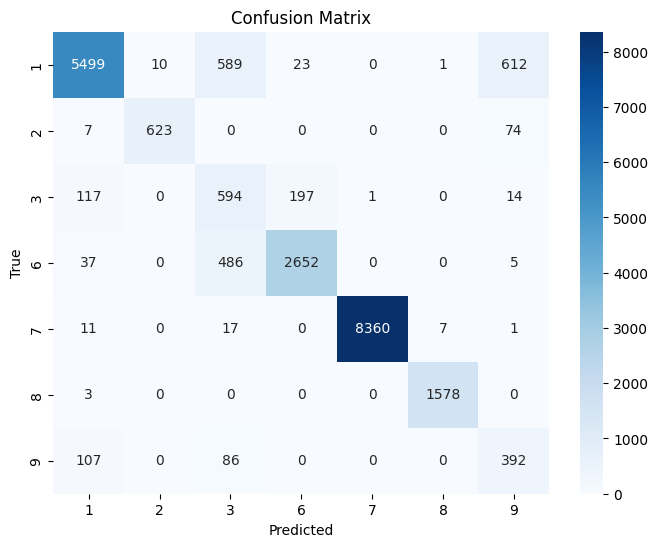

In [83]:
model, cm = run_cnn_bilstm_focal_softweight(
    X_windows_enmo,
    y_windows,
    X_windows_test_enmo,
    y_test_windows
)